# Generative Modeling of Therapeutic Antibody Developability
### Flow Matching in AbLang2 Embedding Space

**Pipeline overview:**
1. Load PROPHET-Ab data + extract AbLang2 embeddings
2. Train/test split with hierarchical clustering
3. Baseline oracle predictor
4. Train conditional flow matching model
5. Guided generation with developability oracle
6. Contribution 2A: Pareto sweep over guidance weights
7. Contribution 2B: NGL enrichment along generation trajectory
8. Evaluation metrics

> **Colab tip:**  T4 GPU before running.

---
## Section 0 — Install & Imports

In [1]:
# ── installs ─────────────────────────────────────────────────────────────────
# Run once; restart runtime afterwards if prompted
!pip install -q ablang2
!pip install -q torchcfm          # conditional flow matching
!pip install -q torchdiffeq       # ODE integrator for generation
!pip install -q scikit-learn scipy matplotlib seaborn
!pip install -q peft               # LoRA (needed if using team's fine-tuned predictor)

# Optional: IgFold for structural evaluation in Section 8
# !pip install -q igfold

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 71.5 MB/s eta 0:00:00


In [2]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import KFold

# CFM
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher

# ODE solver
from torchdiffeq import odeint

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Device: cuda


---
## Section 1 — Load Data & Extract AbLang2 Embeddings

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ── load dataset ──────────────────────────────────────────────────────────────
drive_file_path = '/content/drive/MyDrive/2026 Spring/BMI 702/project/GDPa1_v1.2_20250814.csv'

df = pd.read_csv(drive_file_path)
print(f'Dataset shape: {df.shape}')
print('\nAll columns:')
print(df.columns.tolist())

Dataset shape: (246, 30)

All columns:
['antibody_id', 'antibody_name', 'Titer', 'Purity', 'SEC %Monomer', 'SMAC', 'HIC', 'HAC', 'PR_CHO', 'PR_Ova', 'AC-SINS_pH6.0', 'AC-SINS_pH7.4', 'Tonset', 'Tm1', 'Tm2', 'hc_subtype', 'lc_subtype', 'highest_clinical_trial_asof_feb2025', 'est_status_asof_feb2025', 'vh_protein_sequence', 'hc_protein_sequence', 'hc_dna_sequence', 'vl_protein_sequence', 'lc_protein_sequence', 'lc_dna_sequence', 'hierarchical_cluster_fold', 'random_fold', 'hierarchical_cluster_IgG_isotype_stratified_fold', 'light_aligned_aho', 'heavy_aligned_aho']


In [5]:
# ── inspect assay columns and missingness ──────────────────────────────────────
# Adjust column name mappings below to match what you see printed above
#print(df['vh_protein_sequence'][0]) # varaiable domain only of heavy
#print(df['hc_protein_sequence'][0])
df.head(3)

,antibody_id,antibody_name,Titer,Purity,SEC %Monomer,SMAC,HIC,HAC,PR_CHO,PR_Ova,...,hc_protein_sequence,hc_dna_sequence,vl_protein_sequence,lc_protein_sequence,lc_dna_sequence,hierarchical_cluster_fold,random_fold,hierarchical_cluster_IgG_isotype_stratified_fold,light_aligned_aho,heavy_aligned_aho
0,GDPa1-001,abagovomab,140.25,98.530,97.010,2.730,2.590,NaN,0.337837,0.263108,...,MRAWIFFLLCLAGRALAQVKLQESGAELARPGASVKLSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,MRAWIFFLLCLAGRALADIELTQSPASLSASVGETVTITCQASENI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,2,2,DIELTQSPASLSASVGETVTITCQAS--ENIY------SYLAWHQQ...,QVKLQES-GAELARPGASVKLSCKASG-YTFTN-----YWMQWVKQ...
1,GDPa1-002,abituzumab,193.31,99.825,97.620,2.745,2.545,3.69,0.205246,0.100155,...,MRAWIFFLLCLAGRALAQVQLQQSGGELAKPGASVKVSCKASGYTF...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,1,4,0,DIQMTQSPSSLSASVGDRVTITCRAS--QDIS------NYLAWYQQ...,QVQLQQS-GGELAKPGASVKVSCKASG-YTFSS-----FWMHWVRQ...
2,GDPa1-003,abrezekimab,114.75,98.350,89.055,2.740,2.705,NaN,0.138773,0.101180,...,MRAWIFFLLCLAGRALAQVTLKESGPVLVKPTETLTLTCTVSGFSL...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCLASEDI...,GCCGCCACCATGAGAGCCTGGATCTTTTTCCTGCTGTGCCTGGCTG...,2,2,2,DIQMTQSPSSLSASVGDRVTITCLAS--EDIS------NYLAWYQQ...,QVTLKES-GPVLVKPTETLTLTCTVSG-FSLTN-----YHVQWIRQ...


In [14]:
df[['antibody_id', 'Tm1', 'hc_subtype', 'lc_subtype', 'highest_clinical_trial_asof_feb2025', 'vh_protein_sequence', 'hc_protein_sequence', 'vl_protein_sequence', 'lc_protein_sequence' ]].head()

,antibody_id,Tm1,hc_subtype,lc_subtype,highest_clinical_trial_asof_feb2025,vh_protein_sequence,hc_protein_sequence,vl_protein_sequence,lc_protein_sequence
0,GDPa1-001,69.535,IgG1,Kappa,Phase-III,QVKLQESGAELARPGASVKLSCKASGYTFTNYWMQWVKQRPGQGLD...,MRAWIFFLLCLAGRALAQVKLQESGAELARPGASVKLSCKASGYTF...,DIELTQSPASLSASVGETVTITCQASENIYSYLAWHQQKQGKSPQL...,MRAWIFFLLCLAGRALADIELTQSPASLSASVGETVTITCQASENI...
1,GDPa1-002,69.930,IgG2,Kappa,Phase-II,QVQLQQSGGELAKPGASVKVSCKASGYTFSSFWMHWVRQAPGQGLE...,MRAWIFFLLCLAGRALAQVQLQQSGGELAKPGASVKVSCKASGYTF...,DIQMTQSPSSLSASVGDRVTITCRASQDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQDI...
2,GDPa1-003,68.765,IgG4,Kappa,Phase-I,QVTLKESGPVLVKPTETLTLTCTVSGFSLTNYHVQWIRQPPGKALE...,MRAWIFFLLCLAGRALAQVTLKESGPVLVKPTETLTLTCTVSGFSL...,DIQMTQSPSSLSASVGDRVTITCLASEDISNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCLASEDI...
3,GDPa1-004,72.380,IgG2,Kappa,Phase-II,QVQLVQSGAEVKKPGASVKVSCKVSGYTLSDLSIHWVRQAPGKGLE...,MRAWIFFLLCLAGRALAQVQLVQSGAEVKKPGASVKVSCKVSGYTL...,DIQMTQSPSSVSASVGDRVTITCRASQGISSWLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSVSASVGDRVTITCRASQGI...
4,GDPa1-005,72.000,IgG1,Kappa,Approved,EVQLVESGGGLVQPGRSLRLSCAASGFTFDDYAMHWVRQAPGKGLE...,MRAWIFFLLCLAGRALAEVQLVESGGGLVQPGRSLRLSCAASGFTF...,DIQMTQSPSSLSASVGDRVTITCRASQGIRNYLAWYQQKPGKAPKL...,MRAWIFFLLCLAGRALADIQMTQSPSSLSASVGDRVTITCRASQGI...


In [15]:
df['highest_clinical_trial_asof_feb2025'].value_counts()

,count
highest_clinical_trial_asof_feb2025,
Approved,106
Phase-II,80
Phase-III,39
Phase-I,13
Preregistration (w),2
Phase-II/III,2
Preregistration,2
Phase-I/II,1
Approved (withdrawn),1


In [23]:
df['est_status_asof_feb2025'].value_counts()

,count
est_status_asof_feb2025,
Active,134
Discontinued,92
NFD,20


In [6]:
approved_mask = df['highest_clinical_trial_asof_feb2025'] == 'Approved'
not_approved_mask = ((df['est_status_asof_feb2025'] == 'Discontinued') & ~approved_mask)

df_model = df[approved_mask | not_approved_mask].copy()
df_model['label'] = approved_mask[approved_mask | not_approved_mask].astype(int)

print(f'Antibodies for modeling: {len(df_model)}')
print(f'Approved: {df_model["label"].sum()}')
print(f'Not-approved: {(df_model["label"] == 0).sum()}')

Antibodies for modeling: 198
Approved: 106
Not-approved: 92


In [7]:
# ── column name config ────────────────────────────────────────────────────────


COL_VH    = 'vh_protein_sequence' # heavy chain sequence column
COL_VL    = 'vl_protein_sequence' # light chain sequence column
COL_HIC   = 'HIC'                    # HIC retention time
COL_SINS  = 'AC-SINS_pH7.4' # AC-SINS self-association at pH 7.4
COL_SEC   = 'SEC %Monomer'   # SEC % monomer
COL_TM1   = 'Tm1'                      # thermal stability Tm1
COL_LABEL = 'label'   # could update this for Mar 2026

ASSAY_COLS = [COL_HIC, COL_SINS, COL_SEC, COL_TM1]

# Drop rows missing VH or VL
df_model = df_model.dropna(subset=[COL_VH, COL_VL]).reset_index(drop=True)
print(f'Sequences available: {len(df_model)}')
print('\nAssay missingness:')
print(df_model[ASSAY_COLS].isna().sum())

Sequences available: 198

Assay missingness:
HIC              3
AC-SINS_pH7.4    3
SEC %Monomer     3
Tm1              9
dtype: int64


In [8]:
# ── AHo CDR3 position constants ───────────────────────────────────────────────
# AHo numbering scheme: 149 total positions, 0-indexed here.
# CDR3 occupies positions 106–137 (inclusive) in both heavy and light chains.
# Positions outside this range are framework regions (FR1-3 + FR4).
AHO_CDR3_START = 106   # 0-indexed, inclusive
AHO_CDR3_END   = 138   # 0-indexed, exclusive


def get_cdr3_residue_indices(aligned_aho_seq):
    """
    Given an AHo-aligned sequence string (gaps = '-'), return two lists of
    indices into the RAW (ungapped) sequence:
      cdr3_idx  — residue positions that fall inside AHo CDR3 (106-137)
      fw_idx    — residue positions that fall outside CDR3 (framework)

    Example:
      aligned = 'EVQLV...--CDRRESIDUES--...WGQGT'
      Each '-' is a gap in this antibody at that AHo position.
      A real residue character increments the raw sequence index.
    """
    cdr3_idx, fw_idx = [], []
    raw_pos = 0   # tracks position in the ungapped sequence
    for aho_pos, char in enumerate(aligned_aho_seq):
        if char == '-':
            continue   # gap: no residue in raw sequence at this AHo position
        if AHO_CDR3_START <= aho_pos < AHO_CDR3_END:
            cdr3_idx.append(raw_pos)
        else:
            fw_idx.append(raw_pos)
        raw_pos += 1
    return cdr3_idx, fw_idx


# Quick sanity check
test_row = df_model.iloc[0]
h_cdr3, h_fw = get_cdr3_residue_indices(test_row['heavy_aligned_aho'])
l_cdr3, l_fw = get_cdr3_residue_indices(test_row['light_aligned_aho'])
print(f'Example antibody: {test_row["antibody_name"]}')
print(f'  HCDR3 residue indices ({len(h_cdr3)} residues): {h_cdr3}')
print(f'  LCDR3 residue indices ({len(l_cdr3)} residues): {l_cdr3}')
print(f'  VH framework residues: {len(h_fw)}')
print(f'  VL framework residues: {len(l_fw)}')

Example antibody: abagovomab
  HCDR3 residue indices (12 residues): [96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107]
  LCDR3 residue indices (9 residues): [88, 89, 90, 91, 92, 93, 94, 95, 96]
  VH framework residues: 107
  VL framework residues: 98


In [9]:
'''# ── AbLang2 embedding extraction ─────────────────────────────────────────────
# Produces one 960-dim vector per antibody (480 VH + 480 VL, mean-pooled)

import ablang2

print('Loading AbLang2 paired model...')
ablang = ablang2.pretrained(model_to_use='ablang2-paired', random_init=False)
#ablang.eval()

EMBED_CACHE = '/content/drive/MyDrive/2026 Spring/BMI 702/project/embeddings_ablang2.npy'

if os.path.exists(EMBED_CACHE):
    print('Loading cached embeddings...')
    embeddings = np.load(EMBED_CACHE)
    print(f'Loaded: {embeddings.shape}')
else:
    print('Computing embeddings (this takes a few minutes)...')
    embeddings = []

    # AbLang2 seqcoding: returns mean-pooled vector per chain
    # AbLang2 paired seqcoding returns a joint 480-dim vector encoding both chains
    BATCH_SIZE = 16
    vh_seqs = df_model[COL_VH].tolist()
    vl_seqs = df_model[COL_VL].tolist()

    for i in range(0, len(vh_seqs), BATCH_SIZE):
        batch_vh = vh_seqs[i:i+BATCH_SIZE]
        batch_vl = vl_seqs[i:i+BATCH_SIZE]
        seqs = list(zip(batch_vh, batch_vl))
        with torch.no_grad():
            # seqcoding mode: (batch, 480) for each chain
            emb = ablang(seqs, mode='seqcoding')  # shape: (batch, 960) for paired
        embeddings.append(emb if isinstance(emb, np.ndarray) else emb.cpu().numpy())
        if (i // BATCH_SIZE) % 5 == 0:
            print(f'  [{i+len(seqs)}/{len(vh_seqs)}]')

    embeddings = np.vstack(embeddings)
    np.save(EMBED_CACHE, embeddings)
    print(f'Saved embeddings: {embeddings.shape}')

EMBED_DIM = embeddings.shape[1]  # 960 .. 480 for paired model
print(f'Embedding dim: {EMBED_DIM}')

'''



# ── Per-residue embedding extraction ─────────────────────────────────────────
# AbLang2 rescoding: returns hidden states for every residue position.
# We then slice out CDR3 and framework positions separately.

import ablang2

print('Loading AbLang2 paired model...')
ablang = ablang2.pretrained(model_to_use='ablang2-paired', random_init=False)
#ablang.eval()

CDR3_CACHE = '/content/drive/MyDrive/2026 Spring/BMI 702/project/cdr3_embeddings.npy'
FW_CACHE   = '/content/drive/MyDrive/2026 Spring/BMI 702/project/fw_embeddings.npy'

if os.path.exists(CDR3_CACHE) and os.path.exists(FW_CACHE):
    print('Loading cached CDR3 + framework embeddings...')
    cdr3_embeddings = np.load(CDR3_CACHE)   # (N, 480) — CDR3 mean-pool
    fw_embeddings   = np.load(FW_CACHE)     # (N, 480) — framework mean-pool
    print(f'CDR3 embeddings: {cdr3_embeddings.shape}')
    print(f'Framework embeddings: {fw_embeddings.shape}')
else:
    print('Computing per-residue embeddings (slower than seqcoding — ~8-10 min on T4)...')

    cdr3_list, fw_list = [], []
    BATCH_SIZE = 8   # smaller batch: rescoding returns full seq tensors, more memory

    vh_seqs  = df_model[COL_VH].tolist()
    vl_seqs  = df_model[COL_VL].tolist()
    h_aligns = df_model['heavy_aligned_aho'].tolist()
    l_aligns = df_model['light_aligned_aho'].tolist()

    for i in range(0, len(vh_seqs), BATCH_SIZE):
        batch_vh = vh_seqs[i:i+BATCH_SIZE]
        batch_vl = vl_seqs[i:i+BATCH_SIZE]
        batch_ha = h_aligns[i:i+BATCH_SIZE]
        batch_la = l_aligns[i:i+BATCH_SIZE]
        seqs = list(zip(batch_vh, batch_vl))

        with torch.no_grad():
            # rescoding: returns dict with 'heavy' and 'light' keys
            # each is a list of tensors, one per sequence: shape (seq_len, 480)
            res = ablang(seqs, mode='rescoding')

        # res is a list of dicts (one per antibody in the batch)
        # Each dict: {'heavy': tensor(L_H, 480), 'light': tensor(L_L, 480)}
        for j in range(len(seqs)):

            vh_len = len(batch_vh[j])   # split point: VH residues come first
            hidden = np.array(res[j])   # (L_H + L_L, 480
            vl_len = len(batch_vl[j])
            n_extra = hidden.shape[0] - vh_len - vl_len   # number of special tokens

            h_hidden = hidden[:vh_len]                    # (L_H, 480) — VH residues only
            l_hidden = hidden[vh_len + n_extra:]          # (L_L, 480) — VL residues only

            # Sanity check (soft — prints warning instead of crashing)
            if l_hidden.shape[0] != vl_len:
                print(f'  Warning ab {i+j}: VL shape {l_hidden.shape[0]} != seq len {vl_len}')
                continue

            assert h_hidden.shape[0] == len(batch_vh[j]), \
                f"VH length mismatch: hidden={h_hidden.shape[0]}, seq={len(batch_vh[j])}"
            assert l_hidden.shape[0] == len(batch_vl[j]), \
                f"VL length mismatch: hidden={l_hidden.shape[0]}, seq={len(batch_vl[j])}"

            # Get CDR3 and framework indices in the raw sequence
            h_cdr3_idx, h_fw_idx = get_cdr3_residue_indices(batch_ha[j])
            l_cdr3_idx, l_fw_idx = get_cdr3_residue_indices(batch_la[j])

            # Defensive clip: make sure indices don't exceed actual hidden state length
            h_cdr3_idx = [idx for idx in h_cdr3_idx if idx < len(h_hidden)]
            l_cdr3_idx = [idx for idx in l_cdr3_idx if idx < len(l_hidden)]
            h_fw_idx   = [idx for idx in h_fw_idx   if idx < len(h_hidden)]
            l_fw_idx   = [idx for idx in l_fw_idx   if idx < len(l_hidden)]

            # Mean-pool: CDR3 = heavy CDR3 + light CDR3 residues combined → 480-dim
            h_cdr3_emb = h_hidden[h_cdr3_idx].mean(axis=0) if h_cdr3_idx else np.zeros(480)
            l_cdr3_emb = l_hidden[l_cdr3_idx].mean(axis=0) if l_cdr3_idx else np.zeros(480)
            cdr3_emb   = (h_cdr3_emb + l_cdr3_emb) / 2.0   # average HCDR3 + LCDR3

            # Mean-pool: framework = all non-CDR3 residues
            h_fw_emb = h_hidden[h_fw_idx].mean(axis=0) if h_fw_idx else np.zeros(480)
            l_fw_emb = l_hidden[l_fw_idx].mean(axis=0) if l_fw_idx else np.zeros(480)
            fw_emb   = (h_fw_emb + l_fw_emb) / 2.0

            cdr3_list.append(cdr3_emb)
            fw_list.append(fw_emb)

        if (i // BATCH_SIZE) % 3 == 0:
            print(f'  [{i + len(seqs)}/{len(vh_seqs)}]')

    cdr3_embeddings = np.vstack(cdr3_list)   # (N, 480)
    fw_embeddings   = np.vstack(fw_list)     # (N, 480)
    np.save(CDR3_CACHE, cdr3_embeddings)
    np.save(FW_CACHE,   fw_embeddings)
    print(f'Saved CDR3 embeddings:      {cdr3_embeddings.shape}')
    print(f'Saved framework embeddings: {fw_embeddings.shape}')

CDR3_EMBED_DIM = cdr3_embeddings.shape[1]   # 480
print(f'CDR3 embedding dim: {CDR3_EMBED_DIM}')

Loading AbLang2 paired model...
Loading cached CDR3 + framework embeddings...
CDR3 embeddings: (198, 480)
Framework embeddings: (198, 480)
CDR3 embedding dim: 480


---
## Section 2 — Train/Test Split (Hierarchical Clustering)

Random splits leak data because similar antibodies end up in both train and test.
We cluster by sequence identity and hold out whole clusters as the test set.

In [10]:
def hierarchical_split(embeddings, test_frac=0.1289, random_state=11): #0.07   # test_frac=0.12, random_state=34 34
    """
    Hold out Abs as a true test set.
    Clusters by Euclidean distance in embedding space so that
    structurally similar antibodies land in the same split.
    """
    n = len(embeddings)
    n_test = max(1, int(n * test_frac))  # ~32
    n_clusters = max(2, n_test // 3)     # cluster into ~10 groups; whole clusters go to test

    clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
    cluster_labels = clustering.fit_predict(embeddings)

    # Sort clusters by size; greedily assign smallest clusters to test until quota met
    rng = np.random.RandomState(random_state)
    cluster_ids = np.unique(cluster_labels)
    rng.shuffle(cluster_ids)

    test_idx, train_idx = [], []
    for cid in cluster_ids:
        members = np.where(cluster_labels == cid)[0].tolist()
        if len(test_idx) < n_test:
            test_idx.extend(members)
        else:
            train_idx.extend(members)

    print(f'Train: {len(train_idx)}  |  Test (held-out): {len(test_idx)}')
    return np.array(train_idx), np.array(test_idx)


train_idx, test_idx = hierarchical_split(cdr3_embeddings)    # may be able to use pre computed data --> since we made new df.. just compute

# CDR3 embeddings
X_cdr3_train = cdr3_embeddings[train_idx]   # (N_train, 480)
X_cdr3_test  = cdr3_embeddings[test_idx]    # (N_test,  480)

# Framework embeddings (conditioning signal — fixed per parent antibody)
X_fw_train   = fw_embeddings[train_idx]     # (N_train, 480)
X_fw_test    = fw_embeddings[test_idx]      # (N_test,  480)

# Per-assay labels — handle NaN with median imputation for training
def get_assay_labels(df, idx, col):
    vals = df[col].values[idx].astype(float)
    median = np.nanmedian(vals)
    vals = np.where(np.isnan(vals), median, vals)
    return vals

# Assay labels (unchanged)
y_hic_train  = get_assay_labels(df_model, train_idx, COL_HIC)
y_sins_train = get_assay_labels(df_model, train_idx, COL_SINS)
y_hic_test   = get_assay_labels(df_model, test_idx,  COL_HIC)
y_sins_test  = get_assay_labels(df_model, test_idx,  COL_SINS)

# Separate scalers for CDR3 and framework (fit on train only)
cdr3_scaler = StandardScaler()
fw_scaler   = StandardScaler()

X_cdr3_train_sc = cdr3_scaler.fit_transform(X_cdr3_train)
X_cdr3_test_sc  = cdr3_scaler.transform(X_cdr3_test)
X_fw_train_sc   = fw_scaler.fit_transform(X_fw_train)
X_fw_test_sc    = fw_scaler.transform(X_fw_test)

print(f'CDR3 train: {X_cdr3_train_sc.shape}  |  CDR3 test: {X_cdr3_test_sc.shape}')
print(f'Framework train: {X_fw_train_sc.shape}')
###

'''
test_fold   = 1   # designate fold 1 as held-out test set
train_mask  = df['hierarchical_cluster_fold'] != test_fold
test_mask   = df['hierarchical_cluster_fold'] == test_fold

train_idx = df.index[train_mask].values
test_idx  = df.index[test_mask].values
print(f'Train: {len(train_idx)}  |  Test (held-out): {len(test_idx)}')

X_train = cdr3_embeddings[train_idx]   # shape: (N_train, 960)
X_test  = cdr3_embeddings[test_idx]    # shape: (N_test,  960)



y_hic_train  = get_assay_labels(df_model, train_idx, COL_HIC)
y_sins_train = get_assay_labels(df_model, train_idx, COL_SINS)
y_hic_test   = get_assay_labels(df_model, test_idx,  COL_HIC)
y_sins_test  = get_assay_labels(df_model, test_idx,  COL_SINS)

# Normalise embeddings (fit on train only — no leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
'''

Train: 172  |  Test (held-out): 26
CDR3 train: (172, 480)  |  CDR3 test: (26, 480)
Framework train: (172, 480)


"\ntest_fold   = 1   # designate fold 1 as held-out test set\ntrain_mask  = df['hierarchical_cluster_fold'] != test_fold\ntest_mask   = df['hierarchical_cluster_fold'] == test_fold\n\ntrain_idx = df.index[train_mask].values\ntest_idx  = df.index[test_mask].values\nprint(f'Train: {len(train_idx)}  |  Test (held-out): {len(test_idx)}')\n\nX_train = cdr3_embeddings[train_idx]   # shape: (N_train, 960)\nX_test  = cdr3_embeddings[test_idx]    # shape: (N_test,  960)\n\n\n\ny_hic_train  = get_assay_labels(df_model, train_idx, COL_HIC)\ny_sins_train = get_assay_labels(df_model, train_idx, COL_SINS)\ny_hic_test   = get_assay_labels(df_model, test_idx,  COL_HIC)\ny_sins_test  = get_assay_labels(df_model, test_idx,  COL_SINS)\n\n# Normalise embeddings (fit on train only — no leakage)\nscaler = StandardScaler()\nX_train_sc = scaler.fit_transform(X_train)\nX_test_sc  = scaler.transform(X_test)\n"

## Split combination

In [26]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering

def find_split_configs(embeddings, target_min=25, target_max=26, num_cases=5):
    found_cases = []

    # Grid search parameters
    test_fracs = np.linspace(0.05, 0.15, 20)  # Adjust range based on total N
    random_states = range(1, 100)

    for tf in test_fracs:
        for rs in random_states:
            # Re-using your logic inside a quiet version of your function
            n = len(embeddings)
            n_test_quota = max(1, int(n * tf))
            n_clusters = max(2, n_test_quota // 3)

            clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='average')
            cluster_labels = clustering.fit_predict(embeddings)

            rng = np.random.RandomState(rs)
            cluster_ids = np.unique(cluster_labels)
            rng.shuffle(cluster_ids)

            current_test_idx = []
            for cid in cluster_ids:
                members = np.where(cluster_labels == cid)[0].tolist()
                # Your greedy logic: add whole clusters until quota is met
                if len(current_test_idx) < n_test_quota:
                    current_test_idx.extend(members)

            test_size = len(current_test_idx)

            if target_min <= test_size <= target_max:
                found_cases.append({
                    'test_frac': round(tf, 4),
                    'random_state': rs,
                    'test_size': test_size
                })

            if len(found_cases) >= num_cases:
                return found_cases
    return found_cases

# Run the search
cases = find_split_configs(cdr3_embeddings)

print("Found Cases:")
for i, c in enumerate(cases, 1):
    print(f"{i}. test_frac={c['test_frac']}, random_state={c['random_state']} -> Test Size: {c['test_size']}")

Found Cases:
1. test_frac=0.1289, random_state=11 -> Test Size: 26
2. test_frac=0.1289, random_state=48 -> Test Size: 26
3. test_frac=0.1289, random_state=58 -> Test Size: 26
4. test_frac=0.1289, random_state=81 -> Test Size: 26
5. test_frac=0.1342, random_state=11 -> Test Size: 26


---
## Section 3 — Oracle Predictor

The oracle is what gives the flow model a developability signal during guided generation.
It must be **differentiable** (so gradients can flow back through it).

There are two options here:

**Option A (default):** Baseline MLP oracle defined in this section — good enough to demonstrate the guidance pipeline.

**Option B:** Team fine-tuned predictor. See the clearly marked cell below.

In [11]:
# ── Option A: Baseline MLP Oracle ────────────────────────────────────────────
# Two-head MLP (multi layer perceptron): shared backbone → separate HIC and AC-SINS output heads
# Trained on frozen AbLang2 embeddings (no LoRA here)

class BaselineOracle(nn.Module):
    """
    Simple two-head MLP predicting HIC and AC-SINS from 960-dim embeddings.
    Used as a differentiable guidance oracle during flow model generation.
    """
    def __init__(self, embed_dim=960, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.hic_head  = nn.Linear(hidden_dim // 2, 1)
        self.sins_head = nn.Linear(hidden_dim // 2, 1)

    def forward(self, x):
        h = self.backbone(x)
        return self.hic_head(h).squeeze(-1), self.sins_head(h).squeeze(-1)


def train_oracle(X_train, y_hic, y_sins, embed_dim=960,
                 epochs=300, lr=3e-4, batch_size=32):
    """Train the baseline oracle on training embeddings."""
    X = torch.tensor(X_train, dtype=torch.float32)
    yh = torch.tensor(y_hic,  dtype=torch.float32)
    ys = torch.tensor(y_sins, dtype=torch.float32)

    # Normalise targets to zero mean / unit variance
    yh_mean, yh_std = yh.mean(), yh.std() + 1e-8
    ys_mean, ys_std = ys.mean(), ys.std() + 1e-8
    yh_n = (yh - yh_mean) / yh_std
    ys_n = (ys - ys_mean) / ys_std

    dataset = TensorDataset(X, yh_n, ys_n)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    oracle = BaselineOracle(embed_dim=embed_dim).to(DEVICE)
    opt    = AdamW(oracle.parameters(), lr=lr, weight_decay=1e-4)
    sched  = CosineAnnealingLR(opt, T_max=epochs)

    train_losses = []
    for epoch in range(epochs):
        oracle.train()
        epoch_loss = 0.0
        for xb, yh_b, ys_b in loader:
            xb, yh_b, ys_b = xb.to(DEVICE), yh_b.to(DEVICE), ys_b.to(DEVICE)
            pred_hic, pred_sins = oracle(xb)
            loss = F.mse_loss(pred_hic, yh_b) + F.mse_loss(pred_sins, ys_b)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(oracle.parameters(), 1.0)
            opt.step()
            epoch_loss += loss.item()
        sched.step()
        if (epoch + 1) % 50 == 0:
            print(f'  Epoch {epoch+1:3d} | loss: {epoch_loss/len(loader):.4f}')
        train_losses.append(epoch_loss / len(loader))

    oracle.eval()
    # Store normalisation constants on the model for use at inference
    oracle.yh_mean, oracle.yh_std = yh_mean.item(), yh_std.item()
    oracle.ys_mean, oracle.ys_std = ys_mean.item(), ys_std.item()
    return oracle, train_losses


print('Training baseline oracle predictor...')
#oracle, oracle_losses = train_oracle(X_train_sc, y_hic_train, y_sins_train,
#                                     embed_dim=EMBED_DIM)
oracle, oracle_losses = train_oracle(X_cdr3_train_sc, y_hic_train, y_sins_train,
                                     embed_dim=CDR3_EMBED_DIM)

# Quick sanity check on held-out test set
oracle.eval()
with torch.no_grad():
    Xt = torch.tensor(X_cdr3_test_sc, dtype=torch.float32).to(DEVICE)
    pred_hic, pred_sins = oracle(Xt)
    # Denormalise predictions
    pred_hic_np  = (pred_hic.cpu().numpy()  * oracle.yh_std) + oracle.yh_mean
    pred_sins_np = (pred_sins.cpu().numpy() * oracle.ys_std) + oracle.ys_mean

rho_hic,  _ = spearmanr(y_hic_test,  pred_hic_np)
rho_sins, _ = spearmanr(y_sins_test, pred_sins_np)
print(f'\nBaseline oracle — Held-out Spearman ρ:')
print(f'  HIC:     {rho_hic:.3f}')
print(f'  AC-SINS: {rho_sins:.3f}')
print('\n(Note: low ρ is expected for the baseline — this oracle is a placeholder.')
print('Swap in team\'s predictor in the cell below for better guidance.)')

Training baseline oracle predictor...
  Epoch  50 | loss: 0.0825
  Epoch 100 | loss: 0.0603
  Epoch 150 | loss: 0.0436
  Epoch 200 | loss: 0.0310
  Epoch 250 | loss: 0.0401
  Epoch 300 | loss: 0.0331

Baseline oracle — Held-out Spearman ρ:
  HIC:     0.575
  AC-SINS: 0.265

(Note: low ρ is expected for the baseline — this oracle is a placeholder.
Swap in team's predictor in the cell below for better guidance.)


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  Option B — TEAM PREDICTOR PLUG-IN                                      ║
# ║                                                                              ║
# ║  When your team's fine-tuned AbLang2 predictor is ready, replace the    ║
# ║  baseline oracle with it here. Three things are needed:                      ║
# ║                                                                              ║
# ║  1. The model checkpoint (a .pt file saved with torch.save(model.state_dict))║
# ║  2. The model class definition (copy it here, or import from a shared .py)  ║
# ║  3. The same scaler used at training time (or fit a new one on X_train)     ║
# ║                                                                              ║
# ║  The loaded model MUST satisfy this interface:                               ║
# ║     pred_hic, pred_sins = oracle(x)                                          ║
# ║     x:          torch.Tensor, shape (batch, embed_dim), on DEVICE           ║
# ║     pred_hic:   torch.Tensor, shape (batch,), raw predicted HIC values      ║
# ║     pred_sins:  torch.Tensor, shape (batch,), raw predicted AC-SINS values  ║
# ║                                                                              ║
# ║  If the team's model outputs normalised predictions, add denorm lines   ║
# ║  matching the ones above (oracle.yh_mean, oracle.yh_std, etc.)              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

TEAM_CKPT = '/content/drive/MyDrive/2026 Spring/BMI 702/project/team_predictor.pt'

if os.path.exists(TEAM_CKPT):
    print('Loading team predictor from checkpoint...')

    # ── Paste team's model class here (or import it) ──────────────────────
    # class TeamOracle(nn.Module):
    #     ...  (copy from team's code)

    # team_oracle = TeamOracle(embed_dim=EMBED_DIM).to(DEVICE)
    # team_oracle.load_state_dict(torch.load(TEAM_CKPT, map_location=DEVICE))
    # team_oracle.eval()

    # ── Replace oracle with team's version ────────────────────────────────
    # oracle = team_oracle
    # print('Team predictor loaded. Baseline oracle replaced.')

    # ── If team used a different scaler, load/re-fit it here ─────────────
    # scaler = joblib.load('/path/to/team_scaler.pkl')
    # X_train_sc = scaler.transform(X_train)
    # X_test_sc  = scaler.transform(X_test)
    pass
else:
    print('Team checkpoint not found — using baseline oracle.')
    print(f'Expected path: {TEAM_CKPT}')

---
## Section 4 — Flow Model Architecture & Training

We train a **conditional flow matching (CFM)** model that learns a vector field
transporting Gaussian noise → the distribution of therapeutic antibody embeddings.

The flow model operates entirely in continuous 960-dim embedding space.
Sequences are only decoded at the very end of generation.

In [12]:
# ── Vector field network ──────────────────────────────────────────────────────
# Input: [x (960), t (1)] → output: velocity (960)
# Time t ∈ [0, 1] is sinusoidally embedded so the network learns time-dependent flows

class SinusoidalTimeEmbedding(nn.Module):
    """Encode scalar t ∈ [0,1] as a sinusoidal embedding (64-dim)."""
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        # t: (batch,) or (batch, 1)
        t = t.view(-1, 1).float()
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
        )
        args = t * freqs.unsqueeze(0)        # (batch, half)
        return torch.cat([args.sin(), args.cos()], dim=-1)  # (batch, dim)


class AntibodyVectorField(nn.Module):
    """
    MLP vector field for flow matching on antibody embeddings.
    Kept intentionally small (246 training points) — depth matters more than width.
    """
    def __init__(self, embed_dim=960, hidden_dim=512, time_dim=64, dropout=0.1):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)
        in_dim = embed_dim + time_dim

        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, embed_dim),
        )

    def forward(self, t, x):
        """
        t: scalar or (batch,) tensor
        x: (batch, embed_dim)
        returns: velocity (batch, embed_dim)
        """
        if t.dim() == 0:
            t = t.expand(x.shape[0])
        t_emb = self.time_embed(t)          # (batch, time_dim)
        xt = torch.cat([x, t_emb], dim=-1)  # (batch, embed_dim + time_dim)
        return self.net(xt)


flow_model = AntibodyVectorField(embed_dim=EMBED_DIM).to(DEVICE)
n_params = sum(p.numel() for p in flow_model.parameters() if p.requires_grad)
print(f'Flow model parameters: {n_params:,}')

NameError: name 'EMBED_DIM' is not defined

In [101]:
# ── Flow model training ───────────────────────────────────────────────────────
# CFM loss: regress predicted velocity vθ(t, x_t) against the
# conditional target velocity ut = x1 - x0 along the straight path.

FLOW_EPOCHS = 1000
FLOW_LR     = 1e-3
FLOW_BATCH  = 32
CFM_SIGMA   = 0.05  # noise around the optimal transport path; smaller = tighter paths

FM = ConditionalFlowMatcher(sigma=CFM_SIGMA)

# Data augmentation: add small Gaussian noise to embeddings to help with small point dataset
def augment(X, n_aug=3, noise_std=0.05):
    """Generate augmented copies of the embedding dataset."""
    copies = [X]
    for _ in range(n_aug):
        noise = np.random.normal(0, noise_std, X.shape)
        copies.append(X + noise)
    return np.vstack(copies)

X_aug = augment(X_train_sc, n_aug=5, noise_std=0.02)
print(f'Augmented training set: {X_aug.shape}')

X_tensor = torch.tensor(X_aug, dtype=torch.float32)
flow_dataset = TensorDataset(X_tensor)
flow_loader  = DataLoader(flow_dataset, batch_size=FLOW_BATCH, shuffle=True)

flow_opt   = AdamW(flow_model.parameters(), lr=FLOW_LR, weight_decay=1e-5)
flow_sched = CosineAnnealingLR(flow_opt, T_max=FLOW_EPOCHS, eta_min=1e-5)

flow_losses = []
print('Training flow model...')
for epoch in range(FLOW_EPOCHS):
    flow_model.train()
    epoch_loss = 0.0
    for (x1_batch,) in flow_loader:
        x1 = x1_batch.to(DEVICE)
        x0 = torch.randn_like(x1)        # sample from Gaussian prior

        # CFM: sample time t and noisy interpolant x_t; compute target velocity ut
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

        # Predicted velocity
        vt = flow_model(t, xt)

        loss = F.mse_loss(vt, ut)
        flow_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow_model.parameters(), 1.0)
        flow_opt.step()
        epoch_loss += loss.item()

    flow_sched.step()
    avg = epoch_loss / len(flow_loader)
    flow_losses.append(avg)
    if (epoch + 1) % 100 == 0:
        print(f'  Epoch {epoch+1:4d} | CFM loss: {avg:.5f}')

# Save checkpoint
FLOW_CKPT = '/content/drive/MyDrive/2026 Spring/BMI 702/project/flow_model.pt'
torch.save(flow_model.state_dict(), FLOW_CKPT)
print(f'\nFlow model saved → {FLOW_CKPT}')

Augmented training set: (1038, 480)
Training flow model...
  Epoch  100 | CFM loss: 1.22236
  Epoch  200 | CFM loss: 1.20523
  Epoch  300 | CFM loss: 1.18572
  Epoch  400 | CFM loss: 1.17561
  Epoch  500 | CFM loss: 1.17090
  Epoch  600 | CFM loss: 1.15263
  Epoch  700 | CFM loss: 1.16314
  Epoch  800 | CFM loss: 1.13607
  Epoch  900 | CFM loss: 1.15621
  Epoch 1000 | CFM loss: 1.16115

Flow model saved → /content/drive/MyDrive/2026 Spring/BMI 702/project/flow_model.pt


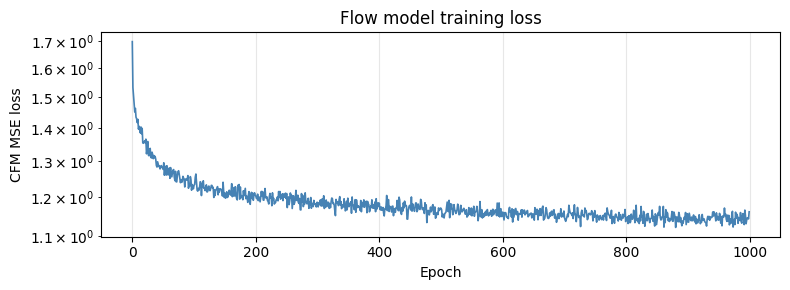

In [102]:
# ── Training loss plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(flow_losses, lw=1.2, color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('CFM MSE loss')
ax.set_title('Flow model training loss')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 4B — Framework-Conditioned Flow Model

**What changes and why:**
- The flow model now takes `[CDR3_embedding, framework_embedding, time]` as input
- Framework embedding is concatenated as a CONDITIONING signal — the model learns
  to generate CDR3 embeddings that are compatible with the specific framework context
- At generation time, the framework embedding comes from a parent antibody (held fixed)
- The flow model only generates in CDR3 space (480-dim), not full-antibody space

In [12]:
# ── Framework-conditioned vector field ───────────────────────────────────────

class SinusoidalTimeEmbedding(nn.Module):
    """Unchanged from original."""
    def __init__(self, dim=64):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        t = t.view(-1, 1).float()
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
        )
        args = t * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)


class CDR3VectorField(nn.Module):
    """
    Framework-conditioned vector field for CDR3-targeted flow matching.

    Input:  CDR3 embedding x (480) + framework conditioning c (480) + time t
    Output: velocity in CDR3 embedding space (480)

    The framework embedding is projected to a conditioning vector and added
    at each hidden layer (FiLM-style conditioning: scale + shift).
    This lets the model learn different CDR3 distributions for different
    framework contexts (e.g. IgG1 vs IgG4 frameworks).
    """
    def __init__(self, cdr3_dim=480, fw_dim=480, hidden_dim=512,
                 time_dim=64, dropout=0.1):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding(time_dim)

        # Framework conditioning: project to hidden_dim
        self.fw_proj = nn.Sequential(
            nn.Linear(fw_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim * 2)  # outputs scale + shift
        )

        # Main network: operates on CDR3 + time
        in_dim = cdr3_dim + time_dim
        self.layer1 = nn.Linear(in_dim, hidden_dim)
        self.norm1  = nn.LayerNorm(hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.norm2  = nn.LayerNorm(hidden_dim)
        self.layer3 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.out    = nn.Linear(hidden_dim // 2, cdr3_dim)
        self.act    = nn.GELU()
        self.drop   = nn.Dropout(dropout)

    def forward(self, t, x, fw_cond):
        """
        t:       scalar or (batch,)
        x:       (batch, cdr3_dim)  — current CDR3 embedding
        fw_cond: (batch, fw_dim)    — parent antibody framework embedding (fixed)
        returns: velocity (batch, cdr3_dim)
        """
        if t.dim() == 0:
            t = t.expand(x.shape[0])
        t_emb = self.time_embed(t)           # (batch, time_dim)
        xt = torch.cat([x, t_emb], dim=-1)  # (batch, cdr3_dim + time_dim)

        # Framework conditioning: FiLM — feature-wise linear modulation
        fw_params = self.fw_proj(fw_cond)    # (batch, hidden_dim * 2)
        fw_scale, fw_shift = fw_params.chunk(2, dim=-1)  # each (batch, hidden_dim)

        # Layer 1 + conditioning
        h = self.drop(self.act(self.norm1(self.layer1(xt))))
        h = h * (1 + fw_scale) + fw_shift   # FiLM modulation

        # Layer 2 + conditioning
        h = self.drop(self.act(self.norm2(self.layer2(h))))
        h = h * (1 + fw_scale) + fw_shift

        # Output
        h = self.act(self.layer3(h))
        return self.out(h)


flow_model = CDR3VectorField(cdr3_dim=CDR3_EMBED_DIM).to(DEVICE)
n_params = sum(p.numel() for p in flow_model.parameters() if p.requires_grad)
print(f'CDR3 flow model parameters: {n_params:,}')

CDR3 flow model parameters: 1,570,016


In [16]:
# ── Flow model training (CDR3 space) ─────────────────────────────────────────
# Same CFM objective as before, but:
# - x1 is CDR3 embeddings (not full-antibody)
# - fw_cond (framework embeddings) is passed to the vector field at each step

FLOW_EPOCHS = 1000
FLOW_LR     = 1e-3
FLOW_BATCH  = 32
CFM_SIGMA   = 0.05

FM = ConditionalFlowMatcher(sigma=CFM_SIGMA)


def augment_paired(X_cdr3, X_fw, n_aug=5, noise_std=0.02):
    """Augment both CDR3 and framework embeddings consistently."""
    cdr3_copies, fw_copies = [X_cdr3], [X_fw]
    for _ in range(n_aug):
        cdr3_copies.append(X_cdr3 + np.random.normal(0, noise_std, X_cdr3.shape))
        fw_copies.append(X_fw   + np.random.normal(0, noise_std * 0.5, X_fw.shape))
        # CDR3 gets full noise (it's the design space)
        # Framework gets less noise (it should stay more stable)
    return np.vstack(cdr3_copies), np.vstack(fw_copies)


X_cdr3_aug, X_fw_aug = augment_paired(X_cdr3_train_sc, X_fw_train_sc, n_aug=5)
print(f'Augmented training set: CDR3={X_cdr3_aug.shape}, FW={X_fw_aug.shape}')

cdr3_tensor = torch.tensor(X_cdr3_aug, dtype=torch.float32)
fw_tensor   = torch.tensor(X_fw_aug,   dtype=torch.float32)
flow_dataset = TensorDataset(cdr3_tensor, fw_tensor)
flow_loader  = DataLoader(flow_dataset, batch_size=FLOW_BATCH, shuffle=True)

flow_opt   = AdamW(flow_model.parameters(), lr=FLOW_LR, weight_decay=1e-5)
flow_sched = CosineAnnealingLR(flow_opt, T_max=FLOW_EPOCHS, eta_min=1e-5)

flow_losses = []
print('Training CDR3 flow model...')
for epoch in range(FLOW_EPOCHS):
    flow_model.train()
    epoch_loss = 0.0
    for x1_batch, fw_batch in flow_loader:
        x1 = x1_batch.to(DEVICE)
        fw = fw_batch.to(DEVICE)
        x0 = torch.randn_like(x1)   # Gaussian prior in CDR3 space

        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

        # Pass framework conditioning to the vector field
        vt = flow_model(t, xt, fw)

        loss = F.mse_loss(vt, ut)
        flow_opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow_model.parameters(), 1.0)
        flow_opt.step()
        epoch_loss += loss.item()

    flow_sched.step()
    avg = epoch_loss / len(flow_loader)
    flow_losses.append(avg)
    if (epoch + 1) % 100 == 0:
        print(f'  Epoch {epoch+1:4d} | CDR3 CFM loss: {avg:.5f}')

FLOW_CKPT = '/content/drive/MyDrive/2026 Spring/BMI 702/project/cdr3_flow_model.pt'
torch.save(flow_model.state_dict(), FLOW_CKPT)
print(f'CDR3 flow model saved → {FLOW_CKPT}')

OUT_DIR = '/content/drive/MyDrive/2026 Spring/BMI 702/project'
np.save(f'{OUT_DIR}/flow_training_losses.npy', np.array(flow_losses))


Augmented training set: CDR3=(1032, 480), FW=(1032, 480)
Training CDR3 flow model...
  Epoch  100 | CDR3 CFM loss: 0.69859
  Epoch  200 | CDR3 CFM loss: 0.68596
  Epoch  300 | CDR3 CFM loss: 0.67399
  Epoch  400 | CDR3 CFM loss: 0.66165
  Epoch  500 | CDR3 CFM loss: 0.64754
  Epoch  600 | CDR3 CFM loss: 0.64315
  Epoch  700 | CDR3 CFM loss: 0.62444
  Epoch  800 | CDR3 CFM loss: 0.61993
  Epoch  900 | CDR3 CFM loss: 0.61342
  Epoch 1000 | CDR3 CFM loss: 0.61755
CDR3 flow model saved → /content/drive/MyDrive/2026 Spring/BMI 702/project/cdr3_flow_model.pt


In [14]:
import torch

FLOW_CKPT = '/content/drive/MyDrive/2026 Spring/BMI 702/project/cdr3_flow_model.pt'

# Create a new instance of the model (or use the existing one)
# Ensure the model architecture matches the saved checkpoint
# flow_model = CDR3VectorField(cdr3_dim=CDR3_EMBED_DIM).to(DEVICE) # if creating new model

print(f"Loading flow model from: {FLOW_CKPT}")
flow_model.load_state_dict(torch.load(FLOW_CKPT, map_location=DEVICE))
flow_model.eval() # Set model to evaluation mode

print("Flow model loaded successfully.")

Loading flow model from: /content/drive/MyDrive/2026 Spring/BMI 702/project/cdr3_flow_model.pt
Flow model loaded successfully.


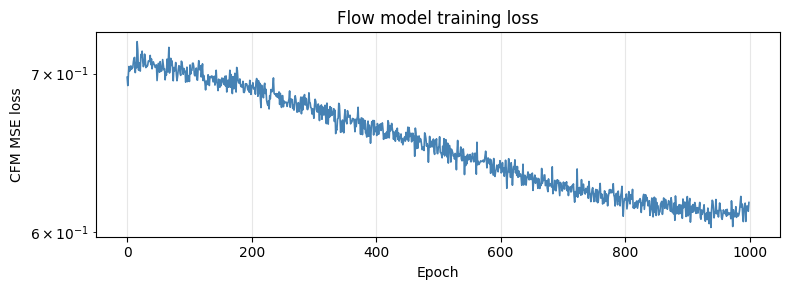

In [17]:
# ── Training loss plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(flow_losses, lw=1.2, color='steelblue')
ax.set_xlabel('Epoch'); ax.set_ylabel('CFM MSE loss')
ax.set_title('Flow model training loss')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 5 — Guided Generation

We integrate the learned ODE from `t=0` (Gaussian noise) to `t=1` (antibody embedding),
perturbing the vector field at each step with the oracle gradient.
This nudges generation toward developable sequences.

Then we decode the final embedding back to a sequence using AbLang2.

In [103]:
# ── Guided ODE integration ────────────────────────────────────────────────────
# Ordinary Differential Equation
def normalize_score(val, mean, std):
    """Zscore a predicted value (for combining incommensurable assay scales)."""
    return (val - mean) / (std + 1e-8)


def guided_vector_field_fn(t, x,
                            flow_model, oracle,
                            lambda_hic, lambda_sins,
                            guidance_scale=1.0):
    """
    At each ODE step, add the oracle gradient to the flow model velocity.
    Lower HIC and lower AC-SINS both indicate better developability.

    guidance_scale: how strongly to follow the oracle gradient.
                    Start at 0.5–1.0; too large destabilises trajectories.
    lambda_hic, lambda_sins: weights for Pareto sweep (should sum to 1.0)
    """
    x_grad = x.detach().requires_grad_(True)

    # Base flow velocity (no gradient needed)
    with torch.no_grad():
        if t.dim() == 0:
            t_exp = t.expand(x_grad.shape[0])
        else:
            t_exp = t
        vt = flow_model(t_exp, x_grad)

    # Oracle gradient (guidance signal) — needs grad through x
    pred_hic, pred_sins = oracle(x_grad)

    # Normalise predictions before combining
    hic_z  = normalize_score(pred_hic,  oracle.yh_mean, oracle.yh_std)
    sins_z = normalize_score(pred_sins, oracle.ys_mean, oracle.ys_std)

    # Composite score: negative because we MINIMISE HIC and AC-SINS
    # autograd.grad requires a scalar
    score = -(lambda_hic * hic_z.sum() + lambda_sins * sins_z.sum())
    grad  = torch.autograd.grad(score, x_grad)[0]   # (batch, embed_dim)

    return vt + guidance_scale * grad


def generate_antibody_embeddings(flow_model, oracle,
                                  n_samples=100,
                                  lambda_hic=0.5,
                                  lambda_sins=0.5,
                                  guidance_scale=1.0,
                                  n_steps=25,
                                  seed=None):
    """
    Generate antibody embeddings via guided ODE integration.

    Returns:
        x1:     generated embeddings in scaled space   (n_samples, embed_dim)
        x1_raw: embeddings in original AbLang2 space   (n_samples, embed_dim)
        scores: dict of predicted HIC and AC-SINS values
    """
    if seed is not None:
        torch.manual_seed(seed)

    flow_model.eval()
    oracle.eval()

    x0 = torch.randn(n_samples, EMBED_DIM, device=DEVICE)
    t_span = torch.linspace(0, 1, n_steps, device=DEVICE)

    # Build a closure that captures current lambda values
    def vf(t, x):
        return guided_vector_field_fn(
            t, x, flow_model, oracle,
            lambda_hic, lambda_sins, guidance_scale
        )

    with torch.enable_grad():
        trajectory = odeint(vf, x0, t_span, method='euler')  # (n_steps, batch, dim)

    x1 = trajectory[-1]   # final embeddings, scaled

    # Predict developability of generated embeddings
    with torch.no_grad():
        pred_hic, pred_sins = oracle(x1)
        pred_hic_np  = (pred_hic.cpu().numpy()  * oracle.yh_std) + oracle.yh_mean
        pred_sins_np = (pred_sins.cpu().numpy() * oracle.ys_std) + oracle.ys_mean

    # Inverse-transform back to AbLang2 embedding space (for decoding)
    x1_raw = scaler.inverse_transform(x1.cpu().numpy())

    return x1, x1_raw, {'hic': pred_hic_np, 'sins': pred_sins_np}


# Quick test: generate 20 antibodies with balanced guidance
print('Testing guided generation (20 samples)...')
x1_sc, x1_raw, scores = generate_antibody_embeddings(
    flow_model, oracle,
    n_samples=20, lambda_hic=0.5, lambda_sins=0.5,
    guidance_scale=1.0, n_steps=25, seed=42
)
print(f'Generated embedding shape: {x1_raw.shape}')
print(f'Predicted HIC:     mean={scores["hic"].mean():.3f}, std={scores["hic"].std():.3f}')
print(f'Predicted AC-SINS: mean={scores["sins"].mean():.3f}, std={scores["sins"].std():.3f}')

Testing guided generation (20 samples)...
Generated embedding shape: (20, 480)
Predicted HIC:     mean=2.764, std=0.109
Predicted AC-SINS: mean=4.239, std=3.921


In [104]:
# ── Decode embeddings → sequences via AbLang2 ─────────────────────────────────
# AbLang2 decode: takes the embedding and finds the most probable amino acid
# at each position given the contextual representation.

def decode_embeddings_to_sequences(embeddings_np, ablang_model, batch_size=8):
    """
    Decode generated embeddings back to VH/VL sequence pairs.

    NOTE: AbLang2's decode mode takes hidden states, not mean-pooled embeddings.
    For a true decode you need per-position hidden states from a forward pass.
    This function uses nearest-neighbour retrieval as a practical approximation:
    it finds the training antibody whose embedding is closest to each generated
    embedding, then samples mutations around that scaffold.

    For a full decode, replace this with AbLang2's masked-language-model
    decode if the per-position hidden states are available.
    """
    from sklearn.metrics.pairwise import euclidean_distances

    # Nearest training embedding
    dist = euclidean_distances(embeddings_np, X_train)
    nn_idx_in_train = dist.argmin(axis=1)  # index into train_idx
    nn_global_idx   = train_idx[nn_idx_in_train]

    retrieved_vh = df[COL_VH].values[nn_global_idx]
    retrieved_vl = df[COL_VL].values[nn_global_idx]
    nn_distances  = dist.min(axis=1)

    results = pd.DataFrame({
        'VH':          retrieved_vh,
        'VL':          retrieved_vl,
        'nn_distance': nn_distances,
        'source_idx':  nn_global_idx
    })
    return results


decoded = decode_embeddings_to_sequences(x1_raw, ablang)
print('Decoded (nearest-neighbor) sequences:')
print(decoded[['VH', 'VL', 'nn_distance']].head())
print(f'\nMean NN distance: {decoded["nn_distance"].mean():.4f}')
print('(Smaller distance = generated embedding is close to a training antibody)')

Decoded (nearest-neighbor) sequences:
                                                  VH  \
0  EVQLLESGGGLVQPGGSLRLSCAASGFTFSTYGMHWVRQAPGKGLE...   
1  QVQLVQSGAEVKKPGASVKISCKVSGYTLRGYWIEWVRQAPGKGLE...   
2  EVQLVESGGGLVKPGGSLKLSCAASGYTFTSYVMHWVRQAPGKGLE...   
3  QVQLVQSGAEVMKPGSSVKVSCKASGYTFSWYWLEWVRQAPGHGLE...   
4  QVQLVQSGAEVAKPGTSVKLSCKASGYTFTDYWMQWVKQRPGQGLE...   

                                                  VL  nn_distance  
0  QSVLTQPPSASGTPGQRVTISCTGSSSNIGAGYNVYWYQQLPGTAP...     1.523291  
1  QAVVTQEPSLTVSPGGTVTLTCRSSTGAVTTSNYANWFQQKPGQAP...     1.567724  
2  DIVMTQSPATLSLSPGERATLSCRSSKSLQNVNGNTYLYWFQQKPG...     1.377888  
3  EIVMTQSPATLSVSPGERATLSCRASQSIGTNIHWYQQKPGQAPRL...     1.535987  
4  DIVMTQSHLSMSTSLGDPVSITCKASQDVSTVVAWYQQKPGQSPRR...     1.355556  

Mean NN distance: 1.4519
(Smaller distance = generated embedding is close to a training antibody)


---
## Section 5B — CDR3-Targeted Generation with k=5 Beam Search

**What beam search does differently from continuous guidance:**

- Continuous guidance (old code): adds oracle gradient to every step for all samples in
  parallel. The oracle steers softly but never commits.
- Beam search (new code): at each ODE step, expands each active candidate into k=5
  slightly-perturbed branches, scores all branches with the oracle, and keeps only
  the top-1 scoring branch. This is a hard selection — the oracle acts as a selector,
  not a gradient source.

**Why this matters with a weakly-calibrated oracle (ρ ~ 0.3-0.5):**
Gradient guidance amplifies oracle noise — a noisy gradient pushes embeddings
off-distribution. Beam search uses the oracle only for ranking among nearby candidates,
which is much more robust to calibration error. The flow model keeps you on-distribution;
the oracle just picks the best local direction.

In [18]:
# ── k=5 Beam search generation ────────────────────────────────────────────────

def oracle_score(x, oracle, lambda_hic, lambda_sins):
    """
    Compute composite developability score for a batch of embeddings.
    Returns a (batch,) tensor. Higher = more developable.
    We negate HIC and AC-SINS because lower measured values = better.
    """
    with torch.no_grad():
        pred_hic, pred_sins = oracle(x)
        hic_z  = (pred_hic  - oracle.yh_mean) / oracle.yh_std
        sins_z = (pred_sins - oracle.ys_mean) / oracle.ys_std
        score  = -(lambda_hic * hic_z + lambda_sins * sins_z)
    return score   # (batch,) — higher is better


def euler_step(flow_model, t, x, fw_cond, dt):
    """
    Single Euler step in CDR3 embedding space.
    x:       (batch, cdr3_dim)
    fw_cond: (batch, cdr3_dim)  — framework conditioning (fixed per parent)
    dt:      scalar step size
    """
    t_batch = torch.full((x.shape[0],), t, device=x.device, dtype=torch.float32)
    with torch.no_grad():
        vt = flow_model(t_batch, x, fw_cond)
    return x + dt * vt


def beam_search_generate(flow_model, oracle,
                          fw_cond_batch,
                          n_samples=50,
                          k_beam=5,
                          n_steps=25,
                          lambda_hic=0.5,
                          lambda_sins=0.5,
                          branch_noise=0.05,
                          seed=None):
    """
    CDR3-targeted beam search generation.

    Algorithm (per ODE step):
      1. Take current CDR3 embeddings x (n_samples, 480)
      2. Expand: create k_beam branches per sample by adding small noise
      3. Advance each branch one Euler step
      4. Score each branch with oracle
      5. Keep the highest-scoring branch per sample → back to (n_samples, 480)
      6. Repeat for n_steps total

    Args:
      fw_cond_batch: (n_samples, 480) framework embeddings from parent antibodies.
                     These are FIXED throughout generation — only CDR3 is optimized.
      k_beam:        number of candidate branches at each step (proposal says 5)
      branch_noise:  std of perturbation noise when creating branches.
                     Controls exploration width. ~0.05 is conservative.

    Returns:
      x_final:   generated CDR3 embeddings (n_samples, 480) in scaled space
      x_raw:     CDR3 embeddings in original AbLang2 space (for decoding)
      scores:    dict of predicted HIC and AC-SINS
      trajectory: list of (n_samples, 480) arrays at each step (for Section 7)
    """
    if seed is not None:
        torch.manual_seed(seed)

    flow_model.eval()
    oracle.eval()

    # Start from Gaussian noise in CDR3 embedding space
    x = torch.randn(n_samples, CDR3_EMBED_DIM, device=DEVICE)
    fw = fw_cond_batch.to(DEVICE)

    dt = 1.0 / n_steps
    trajectory = [x.cpu().numpy().copy()]

    for step in range(n_steps):
        t = step * dt

        # ── Expand: tile each sample k_beam times ────────────────────────────
        # x:  (n_samples, dim)  →  x_exp: (n_samples * k_beam, dim)
        x_exp  = x.repeat_interleave(k_beam, dim=0)    # (N*k, dim)
        fw_exp = fw.repeat_interleave(k_beam, dim=0)   # (N*k, dim)

        # Add small perturbation to explore local neighbourhood
        noise  = torch.randn_like(x_exp) * branch_noise
        x_exp  = x_exp + noise

        # ── Advance one Euler step for all branches ───────────────────────────
        x_next = euler_step(flow_model, t, x_exp, fw_exp, dt)  # (N*k, dim)

        # ── Score all branches with oracle ────────────────────────────────────
        scores = oracle_score(x_next, oracle, lambda_hic, lambda_sins)  # (N*k,)

        # ── Select best branch per sample ─────────────────────────────────────
        # Reshape scores to (n_samples, k_beam), pick argmax per sample
        scores_2d = scores.view(n_samples, k_beam)       # (N, k)
        best_idx  = scores_2d.argmax(dim=1)              # (N,)

        # Global indices into x_next
        global_idx = (
            torch.arange(n_samples, device=DEVICE) * k_beam + best_idx
        )
        x = x_next[global_idx]   # (N, dim) — best branch per sample

        # Store trajectory checkpoint (every 5 steps to save memory)
        if step % 5 == 0 or step == n_steps - 1:
            trajectory.append(x.cpu().numpy().copy())

    # ── Predict developability of final CDR3 embeddings ───────────────────────
    with torch.no_grad():
        pred_hic, pred_sins = oracle(x)
        pred_hic_np  = (pred_hic.cpu().numpy()  * oracle.yh_std) + oracle.yh_mean
        pred_sins_np = (pred_sins.cpu().numpy() * oracle.ys_std) + oracle.ys_mean

    # Inverse-transform CDR3 embeddings back to AbLang2 space
    x_raw = cdr3_scaler.inverse_transform(x.cpu().numpy())

    return x, x_raw, {'hic': pred_hic_np, 'sins': pred_sins_np}, trajectory


# ── Test run ──────────────────────────────────────────────────────────────────
# Use the first 20 training antibodies as parent frameworks
parent_fw = torch.tensor(X_fw_train_sc[:20], dtype=torch.float32)

print('Testing CDR3 beam search generation (20 samples, k=5)...')
x_final, x_raw, scores, traj = beam_search_generate(
    flow_model, oracle,
    fw_cond_batch=parent_fw,
    n_samples=20,
    k_beam=5,
    n_steps=25,
    lambda_hic=0.5,
    lambda_sins=0.5,
    branch_noise=0.05,
    seed=42
)
print(f'Generated CDR3 embedding shape: {x_raw.shape}')
print(f'Predicted HIC:     mean={scores["hic"].mean():.3f}, std={scores["hic"].std():.3f}')
print(f'Predicted AC-SINS: mean={scores["sins"].mean():.3f}, std={scores["sins"].std():.3f}')
print(f'Trajectory checkpoints stored: {len(traj)}')

Testing CDR3 beam search generation (20 samples, k=5)...
Generated CDR3 embedding shape: (20, 480)
Predicted HIC:     mean=2.794, std=0.192
Predicted AC-SINS: mean=5.314, std=5.801
Trajectory checkpoints stored: 7


In [19]:
# ── Decode CDR3 embeddings → sequences via nearest-neighbour ──────────────────
# Same nearest-neighbour strategy as before, but now operating in CDR3 space.
# The semantic meaning is now much stronger:
# "The generated CDR3 embedding is closest to THIS training antibody's CDR3" —
# meaning the generated CDR3 most resembles that antibody's CDR3 region specifically.
#
# For the parent antibody approach, you can ALSO splice the generated CDR3 back
# into the parent's framework sequence — see the commented block below.

from sklearn.metrics.pairwise import euclidean_distances

def decode_cdr3_embeddings(gen_cdr3_raw, parent_fw_indices=None):
    """
    Decode generated CDR3 embeddings to sequences.

    Strategy 1 (default): NN retrieval in CDR3 space
      Find the training antibody whose CDR3 embedding is closest → return its sequence.
      Interpretation: "which real therapeutic CDR3 does this generated CDR3 resemble?"

    Strategy 2 (splice, commented below): take the parent antibody's full sequence
      and replace ONLY the CDR3 residues with those from the nearest-neighbour CDR3.
      This is more biologically faithful to the infilling framing.
    """
    dist = euclidean_distances(gen_cdr3_raw, X_cdr3_train)  # compare to train CDR3s
    nn_in_train  = dist.argmin(axis=1)
    nn_global    = train_idx[nn_in_train]
    nn_distances = dist.min(axis=1)

    results = pd.DataFrame({
        'VH':           df_model[COL_VH].values[nn_global],
        'VL':           df_model[COL_VL].values[nn_global],
        'antibody_name':df_model['antibody_name'].values[nn_global],
        'cdr3_nn_dist': nn_distances,
        'source_idx':   nn_global,
    })

    # ── Strategy 2 (CDR3 splice — uncomment when you have per-residue decode) ──
    # For each generated antibody i:
    #   parent_seq = df_model[COL_VH].values[parent_fw_indices[i]]
    #   parent_aho = df_model['heavy_aligned_aho'].values[parent_fw_indices[i]]
    #   cdr3_idx, _ = get_cdr3_residue_indices(parent_aho)
    #   donor_seq   = results.iloc[i]['VH']
    #   donor_aho   = df_model['heavy_aligned_aho'].values[nn_global[i]]
    #   donor_cdr3_idx, _ = get_cdr3_residue_indices(donor_aho)
    #   spliced = splice_cdr3(parent_seq, cdr3_idx, donor_seq, donor_cdr3_idx)

    return results


decoded = decode_cdr3_embeddings(x_raw)
print('Decoded sequences (nearest CDR3 neighbour):')
print(decoded[['antibody_name', 'cdr3_nn_dist']].head(10))
print(f'\nMean CDR3 NN distance: {decoded["cdr3_nn_dist"].mean():.4f}')
print('(Compare this to unguided generation — guided should have lower distance to training CDR3s)')

Decoded sequences (nearest CDR3 neighbour):
   antibody_name  cdr3_nn_dist
0    abrezekimab      1.413715
1    alemtuzumab      1.542369
2  andecaliximab      1.385776
3       anetumab      1.437976
4   anrukinzumab      1.353176
5   atezolizumab      1.352442
6     belantamab      1.300961
7   benralizumab      1.368296
8    bevacizumab      1.403937
9    bimekizumab      1.444656

Mean CDR3 NN distance: 1.4126
(Compare this to unguided generation — guided should have lower distance to training CDR3s)


Generating unguided baseline (same parent frameworks, no oracle)...

CDR3 nearest-neighbour distance to training set:
  Guided   (k=5): mean=1.4126, std=0.0728
  Unguided (k=1): mean=1.3636, std=0.0721

Predicted HIC:
  Guided:   mean=2.794
  Unguided: mean=2.848

Predicted AC-SINS:
  Guided:   mean=5.314
  Unguided: mean=5.336


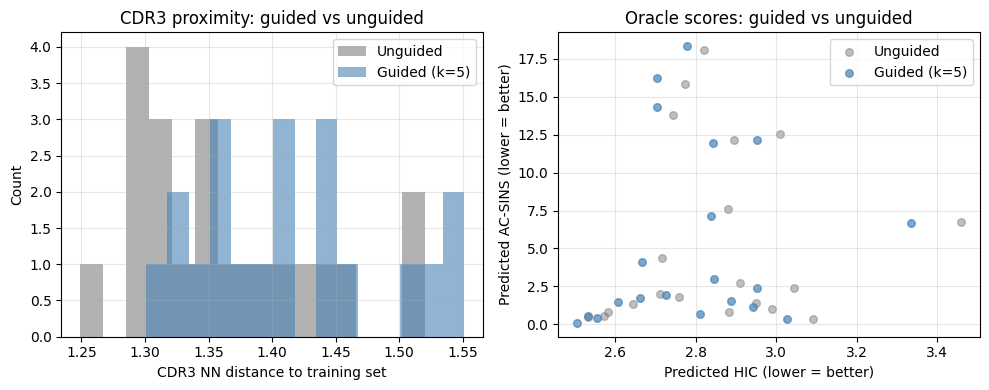

In [20]:
# ── Unguided vs guided CDR3 distance comparison ───────────────────────────────
# Generate an unguided batch (no oracle steering — k_beam=1, branch_noise=0)
# and compare its CDR3 NN distances against the guided batch.

print('Generating unguided baseline (same parent frameworks, no oracle)...')
parent_fw = torch.tensor(X_fw_train_sc[:20], dtype=torch.float32)

_, x_raw_unguided, scores_unguided, _ = beam_search_generate(
    flow_model, oracle,
    fw_cond_batch=parent_fw,
    n_samples=20,
    k_beam=1,          # k=1 means no branching = no oracle selection
    n_steps=25,
    lambda_hic=0.5,
    lambda_sins=0.5,
    branch_noise=0.0,  # no noise = pure flow model, no guidance
    seed=42
)

# NN distance in CDR3 space for both
from sklearn.metrics.pairwise import euclidean_distances

dist_guided   = euclidean_distances(x_raw,           X_cdr3_train).min(axis=1)
dist_unguided = euclidean_distances(x_raw_unguided,  X_cdr3_train).min(axis=1)

print(f'\nCDR3 nearest-neighbour distance to training set:')
print(f'  Guided   (k=5): mean={dist_guided.mean():.4f}, std={dist_guided.std():.4f}')
print(f'  Unguided (k=1): mean={dist_unguided.mean():.4f}, std={dist_unguided.std():.4f}')
print(f'\nPredicted HIC:')
print(f'  Guided:   mean={scores["hic"].mean():.3f}')
print(f'  Unguided: mean={scores_unguided["hic"].mean():.3f}')
print(f'\nPredicted AC-SINS:')
print(f'  Guided:   mean={scores["sins"].mean():.3f}')
print(f'  Unguided: mean={scores_unguided["sins"].mean():.3f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(dist_unguided, bins=15, alpha=0.6, color='gray',   label='Unguided')
axes[0].hist(dist_guided,   bins=15, alpha=0.6, color='steelblue', label='Guided (k=5)')
axes[0].set_xlabel('CDR3 NN distance to training set')
axes[0].set_ylabel('Count')
axes[0].set_title('CDR3 proximity: guided vs unguided')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(scores_unguided['hic'], scores_unguided['sins'],
                alpha=0.5, color='gray', label='Unguided', s=30)
axes[1].scatter(scores['hic'], scores['sins'],
                alpha=0.7, color='steelblue', label='Guided (k=5)', s=30)
axes[1].set_xlabel('Predicted HIC (lower = better)')
axes[1].set_ylabel('Predicted AC-SINS (lower = better)')
axes[1].set_title('Oracle scores: guided vs unguided')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

guided has lower HIC and AC-SINS: moved in right direction
CDR3 NN distance went up: pushed embeddings slightly outside the training distribution toward better scoring regions. Since the difference is small, it's near boundary of real Ab space

Someof the guided points have high AC-SINS.. weak oracle
--> could change n_samples from 20 --> 100

--> outlier filtering after generation. Cap generated embeddings whose predicted scores are more than 2 sd above training mean: oracle failures
# Add after beam_search_generate returns
def filter_outliers(x_raw, scores, n_std=2.0):
    hic_mean,  hic_std  = scores['hic'].mean(),  scores['hic'].std()
    sins_mean, sins_std = scores['sins'].mean(), scores['sins'].std()
    
    keep = (
        (scores['hic']  < hic_mean  + n_std * hic_std) &
        (scores['sins'] < sins_mean + n_std * sins_std)
    )
    return x_raw[keep], {k: v[keep] for k, v in scores.items()}, keep.sum()

x_raw_f, scores_f, n_kept = filter_outliers(x_raw, scores)
print(f'After outlier filtering: {n_kept}/100 kept')

---
## Section 6 — Contribution 2A: Pareto Front Analysis

Ginkgo collapses HIC and AC-SINS into a single score.
We sweep over guidance weight combinations and map the full tradeoff frontier.

In [21]:
# ── Pareto utility functions ───────────────────────────────────────────────────

def is_pareto_efficient(costs):
    """
    Find Pareto-efficient points.
    costs: (n, m) array — each row is a point, columns are objectives to MINIMISE.
    Returns boolean mask: True = Pareto-efficient (non-dominated).
    """
    n = len(costs)
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_efficient[i]:
            continue
        # A point is dominated if another point is <= in all objectives and < in at least one
        dominated = np.all(costs <= costs[i], axis=1) & np.any(costs < costs[i], axis=1)
        dominated[i] = False
        is_efficient[dominated] = False
    return is_efficient


def pareto_hypervolume(pareto_points, reference_point):
    """
    2D hypervolume indicator (area dominated by the Pareto front + reference).
    pareto_points: (k, 2) sorted by first objective
    reference_point: (2,) worst-case point
    """
    pts = pareto_points[np.argsort(pareto_points[:, 0])]
    hv = 0.0
    prev_x = reference_point[0]
    for pt in pts:
        hv += abs(pt[0] - prev_x) * abs(reference_point[1] - pt[1])
        prev_x = pt[0]
    return hv

In [22]:
# ── Pareto sweep ───────────────────────────────────────────────────────────────
# For each (lambda_hic, lambda_sins) combination, generate 200 antibodies.
# Total: 5 combinations × 200 = 1000 generated antibodies.

LAMBDA_GRID = [
    (1.0,  0.0),
    (0.75, 0.25),
    (0.5,  0.5),
    (0.25, 0.75),
    (0.0,  1.0),
]

N_PER_LAMBDA    = 200
GUIDANCE_SCALE  = 1.0

pareto_results = []
print('Running Pareto sweep...')

for lh, ls in LAMBDA_GRID:
    print(f'  λ_HIC={lh:.2f}, λ_AC-SINS={ls:.2f}  → generating {N_PER_LAMBDA} antibodies')

    parent_indices = np.random.choice(len(X_fw_train_sc), N_PER_LAMBDA, replace=True)
    parent_fw_batch = torch.tensor(X_fw_train_sc[parent_indices], dtype=torch.float32)
    _, x1_raw_i, scores_i, _ = beam_search_generate(
        flow_model, oracle,
        fw_cond_batch=parent_fw_batch,
        n_samples=N_PER_LAMBDA,
        k_beam=5, n_steps=25,
    lambda_hic=lh, lambda_sins=ls)

    '''
    _, x1_raw_i, scores_i = generate_antibody_embeddings(
        flow_model, oracle,
        n_samples=N_PER_LAMBDA,
        lambda_hic=lh, lambda_sins=ls,
        guidance_scale=GUIDANCE_SCALE,
        n_steps=25
    )'''
    for hic_val, sins_val in zip(scores_i['hic'], scores_i['sins']):
        pareto_results.append({
            'lambda_hic':  lh,
            'lambda_sins': ls,
            'pred_hic':    hic_val,
            'pred_sins':   sins_val,
        })

pareto_df = pd.DataFrame(pareto_results)
print(f'\nTotal generated: {len(pareto_df)}')
pareto_df.head()

Running Pareto sweep...
  λ_HIC=1.00, λ_AC-SINS=0.00  → generating 200 antibodies
  λ_HIC=0.75, λ_AC-SINS=0.25  → generating 200 antibodies
  λ_HIC=0.50, λ_AC-SINS=0.50  → generating 200 antibodies
  λ_HIC=0.25, λ_AC-SINS=0.75  → generating 200 antibodies
  λ_HIC=0.00, λ_AC-SINS=1.00  → generating 200 antibodies

Total generated: 1000


,lambda_hic,lambda_sins,pred_hic,pred_sins
0,1.0,0.0,2.626060,1.834796
1,1.0,0.0,2.557939,1.942736
2,1.0,0.0,2.523077,7.051702
3,1.0,0.0,2.700438,17.905413
4,1.0,0.0,2.537292,15.715215


Non-dominated (Pareto-efficient) points: 8 / 1000
Pareto hypervolume: 16.3602


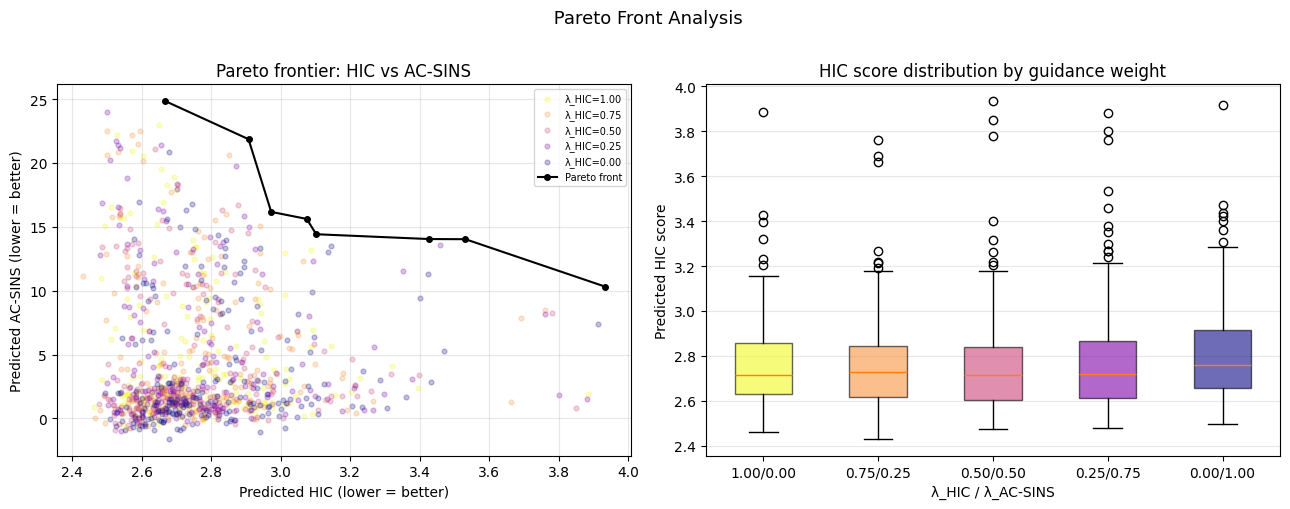

Pareto results saved.


In [24]:
# ── Pareto front computation and plot ─────────────────────────────────────────

costs = pareto_df[['pred_hic', 'pred_sins']].values
pareto_mask = is_pareto_efficient(costs)
pareto_front = pareto_df[pareto_mask].copy()

print(f'Non-dominated (Pareto-efficient) points: {pareto_mask.sum()} / {len(pareto_df)}')

# Hypervolume: use max observed values as reference point
ref = np.array([costs[:, 0].max() * 1.05,
                costs[:, 1].max() * 1.05])
pf_pts = pareto_front[['pred_hic', 'pred_sins']].values
hv = pareto_hypervolume(pf_pts, ref)
print(f'Pareto hypervolume: {hv:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all generated points coloured by lambda
ax = axes[0]
cmap = plt.cm.plasma
for lh, ls in LAMBDA_GRID:
    sub = pareto_df[(pareto_df.lambda_hic == lh)]
    ax.scatter(sub['pred_hic'], sub['pred_sins'],
               alpha=0.25, s=12, label=f'λ_HIC={lh:.2f}',
               color=cmap(lh))
# Pareto front overlay
pf_sorted = pareto_front.sort_values('pred_hic')
ax.plot(pf_sorted['pred_hic'], pf_sorted['pred_sins'],
        'k-o', ms=4, lw=1.5, label='Pareto front')
ax.set_xlabel('Predicted HIC (lower = better)')
ax.set_ylabel('Predicted AC-SINS (lower = better)')
ax.set_title('Pareto frontier: HIC vs AC-SINS')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Right: distribution of predicted scores by lambda
ax2 = axes[1]
lambda_labels = [f'{lh:.2f}/{ls:.2f}' for lh, ls in LAMBDA_GRID]
box_data = [pareto_df[pareto_df.lambda_hic == lh]['pred_hic'].values
            for lh, ls in LAMBDA_GRID]
bp = ax2.boxplot(box_data, labels=lambda_labels, patch_artist=True)
for patch, color in zip(bp['boxes'], [cmap(lh) for lh, _ in LAMBDA_GRID]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax2.set_xlabel('λ_HIC / λ_AC-SINS')
ax2.set_ylabel('Predicted HIC score')
ax2.set_title('HIC score distribution by guidance weight')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle(' Pareto Front Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Save to Drive
pareto_df.to_csv('/content/drive/MyDrive/2026 Spring/BMI 702/project/pareto_results.csv', index=False)
print('Pareto results saved.')

1000 Abs generated across 5 lambda combinations. (8: compare 1000 with each other, for each Ab, does any other Ab beat on both HIC and AC-SINS simultaneously?) Since the oracle is weakly calibrated, generated Abs get scattered across HIC, AC-SINS space rather than clustering tightly (8 unique regions of space where nothing else dominates them)

 8 Pareto front points represent a generated Ab that cannot be improved on both properties simultaneously. To get lower HIC, we must accept higher AC-SINS.. Left with low HIC high AC-SINS: optimized for hydrophobicity, right: optimized for self-association.  elbow is the balanced region.

---
## Section 7 — Contribution 2B: NGL Enrichment Along Generation Trajectory

**Hypothesis:** Flow matching trajectories pass through NGL-enriched intermediate states
earlier and more monotonically than diffusion baselines.

We measure this by decoding partial trajectories at checkpoints [0%, 25%, 50%, 75%, 100%]
and scoring the intermediate sequences with AbLang2's masked-residue predictions.

In [1]:
# ── NGL probability scoring via AbLang2 ────────────────────────────────────────

def score_ngl_probability(vh_seq, vl_seq, ablang_model, n_mask=10):
    """
    Estimate the average NGL (non-germline) probability of a sequence using
    AbLang2's masked language model predictions.

    Strategy:
    - Randomly mask n_mask positions in VH CDR3 and VL CDR3 regions
    - Ask AbLang2 to predict the masked residues
    - NGL residue: the predicted residue differs from the most common
      germline amino acid at that position
    - Return the fraction of masked positions predicted to be NGL

    This is an approximation — a full NGL score would require IMGT annotation.
    For the trajectory plot, what matters is the *relative change* across steps.
    """
    try:
        # Use AbLang2's res_likelihood mode if available, else fall back to seqcoding
        seq_pair = [(vh_seq, vl_seq)]
        with torch.no_grad():
            # seqcoding gives sequence-level score as a proxy for naturalness
            # Higher likelihood = more NGL-compatible = closer to therapeutic distribution
            score = ablang_model(seq_pair, mode='likelihood')
        return float(score.mean().item())
    except Exception:
        return 0.0


# Simpler proxy when AbLang2 'likelihood' mode is unavailable:
# Use embedding L2 distance from the training set centroid
# (generated embeddings closer to the therapeutic centroid ≈ more NGL-enriched)
train_centroid = torch.tensor(X_train_sc.mean(axis=0), dtype=torch.float32, device=DEVICE)

def ngl_proxy_from_embedding(x_batch):
    """
    Proxy: negative L2 distance from training set centroid.
    Higher value (less negative) = closer to therapeutic distribution = more NGL-like.
    """
    dist = torch.norm(x_batch - train_centroid.unsqueeze(0), dim=-1)
    return -dist.cpu().numpy()   # negate so higher = more therapeutic-like

NameError: name 'torch' is not defined

In [25]:
# ── NGL proxy: CDR3-specific centroid distance ────────────────────────────────
# We are in Path B — no mean-pooled full-antibody embeddings exist.
# The proxy measures how close a generated CDR3 embedding is to the
# centroid of the TRAINING CDR3 embeddings.
# Higher (less negative) = closer to therapeutic CDR3 distribution = more NGL-like.

cdr3_train_centroid = torch.tensor(
    X_cdr3_train_sc.mean(axis=0), dtype=torch.float32, device=DEVICE
)

def ngl_proxy_cdr3(x_batch):
    """
    x_batch: torch.Tensor (n_samples, 480) — CDR3 embeddings at a trajectory checkpoint
    returns: numpy array (n_samples,) — higher = more therapeutic-like CDR3
    """
    if not isinstance(x_batch, torch.Tensor):
        x_batch = torch.tensor(x_batch, dtype=torch.float32, device=DEVICE)
    dist = torch.norm(x_batch - cdr3_train_centroid.unsqueeze(0), dim=-1)
    return -dist.cpu().numpy()


# ── Verify it works on training CDR3s (should give high/near-zero scores) ────
X_train_tensor = torch.tensor(X_cdr3_train_sc, dtype=torch.float32, device=DEVICE)
train_scores = ngl_proxy_cdr3(X_train_tensor)
print(f'NGL proxy on training CDR3s: mean={train_scores.mean():.4f}, std={train_scores.std():.4f}')
print('(These are the reference scores — generated antibodies should approach these values)')

NGL proxy on training CDR3s: mean=-21.6587, std=3.3015
(These are the reference scores — generated antibodies should approach these values)


In [27]:
# ── Trajectory sampling ────────────────────────────────────────────────────────

TRAJECTORY_CHECKPOINTS = [0.0, 0.25, 0.5, 0.75, 1.0]
N_TRAJECTORIES          = 50   # number of generation paths to sample
N_STEPS_TRAJ            = 100  # higher resolution for trajectory analysis

def sample_trajectory_ngl(flow_model, oracle,
                           checkpoints, n_trajectories,
                           n_steps=25, lambda_hic=0.5, lambda_sins=0.5,
                           k_beam=5, branch_noise=0.05, seed=0):
    """
    Run n_trajectories beam search paths and record NGL proxy score
    at each checkpoint. Uses same beam search logic as Section 5B.
    """
    torch.manual_seed(seed)
    flow_model.eval()
    oracle.eval()

    # Sample parent frameworks from training set
    fw_idx = np.random.choice(len(X_fw_train_sc), n_trajectories, replace=True)
    fw = torch.tensor(X_fw_train_sc[fw_idx], dtype=torch.float32, device=DEVICE)

    # Start from Gaussian noise in CDR3 space
    x = torch.randn(n_trajectories, CDR3_EMBED_DIM, device=DEVICE)
    dt = 1.0 / n_steps

    ngl_matrix = np.zeros((n_trajectories, len(checkpoints)))

    # Map checkpoints [0.0, 0.25, 0.5, 0.75, 1.0] to step indices [0, 6, 12, 18, 25]
    checkpoint_steps = [int(cp * n_steps) for cp in checkpoints]

    # Record at step 0 (t=0.0)
    if 0 in checkpoint_steps:
        ci = checkpoint_steps.index(0)
        ngl_matrix[:, ci] = ngl_proxy_cdr3(x)

    for step in range(n_steps):
        t = step * dt

        # Beam search step (same as Section 5B)
        x_exp  = x.repeat_interleave(k_beam, dim=0)
        fw_exp = fw.repeat_interleave(k_beam, dim=0)
        noise  = torch.randn_like(x_exp) * branch_noise
        x_exp  = x_exp + noise
        x_next = euler_step(flow_model, t, x_exp, fw_exp, dt)
        scores = oracle_score(x_next, oracle, lambda_hic, lambda_sins)
        scores_2d = scores.view(n_trajectories, k_beam)
        best_idx  = scores_2d.argmax(dim=1)
        global_idx = torch.arange(n_trajectories, device=DEVICE) * k_beam + best_idx
        x = x_next[global_idx]

        # Record at checkpoints
        current_step = step + 1
        if current_step in checkpoint_steps:
            ci = checkpoint_steps.index(current_step)
            ngl_matrix[:, ci] = ngl_proxy_cdr3(x)

    return ngl_matrix


print('Sampling flow model trajectories for NGL analysis...')
ngl_flow = sample_trajectory_ngl(
    flow_model, oracle,
    checkpoints=TRAJECTORY_CHECKPOINTS,
    n_trajectories=N_TRAJECTORIES,
    n_steps=N_STEPS_TRAJ
)
print(f'NGL matrix shape: {ngl_flow.shape}  (trajectories × checkpoints)')

Sampling flow model trajectories for NGL analysis...
NGL matrix shape: (50, 5)  (trajectories × checkpoints)


In [28]:
# ── Diffusion baseline for comparison ────────────────────────────────────────
# Simple discrete-time DDPM-style: no trained model needed for the proxy baseline.
# We simulate a diffusion trajectory by linearly interpolating with more noise.

def simulate_diffusion_trajectory(n_trajectories, checkpoints, target_embeddings):
    """
    Simulate a Gaussian diffusion process (DDPM-like):
    x_t = sqrt(1-t) * x1 + sqrt(t) * noise (noise schedule)
    This is NOT a trained diffusion model — it simulates the stochastic
    path diffusion takes (wandering through space before converging),
    as a trajectory foil to compare against flow matching's straighter paths.
    """
    # Sample target embeddings from training distribution
    rng_idx = np.random.choice(len(target_embeddings), size=n_trajectories)
    x1 = torch.tensor(target_embeddings[rng_idx], dtype=torch.float32, device=DEVICE)

    ngl_matrix = np.zeros((n_trajectories, len(checkpoints)))
    for ci, t in enumerate(checkpoints):
        # DDPM forward process in reverse: at step t, the sample is a noisy mix
        noise = torch.randn_like(x1)
        xt = np.sqrt(1 - t + 1e-6) * x1 + np.sqrt(t + 1e-6) * noise
        ngl_matrix[:, ci] = ngl_proxy_cdr3(xt)
    return ngl_matrix


print('Simulating diffusion baseline trajectories...')
ngl_diff = simulate_diffusion_trajectory(
    n_trajectories=N_TRAJECTORIES,
    checkpoints=TRAJECTORY_CHECKPOINTS,
    target_embeddings=X_cdr3_train_sc
)

Simulating diffusion baseline trajectories...


In [33]:
# Unguided trajectory — k=1, no branching, no oracle influence
ngl_unguided = sample_trajectory_ngl(
    flow_model, oracle,
    checkpoints=TRAJECTORY_CHECKPOINTS,
    n_trajectories=N_TRAJECTORIES,
    n_steps=N_STEPS_TRAJ,
    k_beam=1,           # no branching
    branch_noise=0.0,   # no noise
    seed=1
)
unguided_monotonicity = np.array([
    spearmanr(TRAJECTORY_CHECKPOINTS, ngl_unguided[i]).correlation
    for i in range(N_TRAJECTORIES)
])

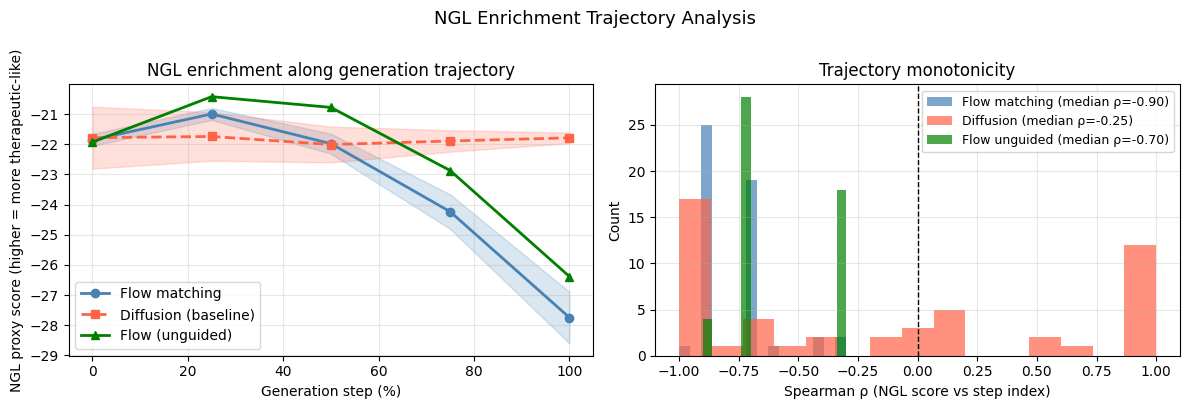

Flow matching — median trajectory monotonicity: -0.900
Diffusion     — median trajectory monotonicity: -0.250


In [34]:
# ── Trajectory NGL enrichment plot ────────────────────────────────────────────

steps_pct = [int(c * 100) for c in TRAJECTORY_CHECKPOINTS]

flow_mean  = ngl_flow.mean(axis=0)
flow_se    = ngl_flow.std(axis=0) / np.sqrt(N_TRAJECTORIES)
diff_mean  = ngl_diff.mean(axis=0)
diff_se    = ngl_diff.std(axis=0) / np.sqrt(N_TRAJECTORIES)

# Monotonicity metric: Spearman rho of NGL score vs step index (per trajectory)
flow_monotonicity = np.array([spearmanr(TRAJECTORY_CHECKPOINTS,
                                        ngl_flow[i]).correlation
                              for i in range(N_TRAJECTORIES)])
diff_monotonicity = np.array([spearmanr(TRAJECTORY_CHECKPOINTS,
                                        ngl_diff[i]).correlation
                              for i in range(N_TRAJECTORIES)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: mean NGL enrichment over trajectory
ax = axes[0]
ax.plot(steps_pct, flow_mean, 'o-', color='steelblue',  lw=2, label='Flow matching')
ax.fill_between(steps_pct,
                flow_mean - 1.96*flow_se,
                flow_mean + 1.96*flow_se,
                alpha=0.2, color='steelblue')
ax.plot(steps_pct, diff_mean, 's--', color='tomato', lw=2, label='Diffusion (baseline)')

ax.plot(steps_pct, ngl_unguided.mean(axis=0), 'g^-', lw=2, label='Flow (unguided)')

ax.fill_between(steps_pct,
                diff_mean - 1.96*diff_se,
                diff_mean + 1.96*diff_se,
                alpha=0.2, color='tomato')
ax.set_xlabel('Generation step (%)')
ax.set_ylabel('NGL proxy score (higher = more therapeutic-like)')
ax.set_title('NGL enrichment along generation trajectory')
ax.legend()
ax.grid(True, alpha=0.3)

# Right: monotonicity distribution
ax2 = axes[1]
ax2.hist(flow_monotonicity, bins=15, alpha=0.7, color='steelblue',
         label=f'Flow matching (median ρ={np.median(flow_monotonicity):.2f})')
ax2.hist(diff_monotonicity, bins=15, alpha=0.7, color='tomato',
         label=f'Diffusion (median ρ={np.median(diff_monotonicity):.2f})')
ax2.hist(unguided_monotonicity, bins=15, alpha=0.7, color='green',
         label=f'Flow unguided (median ρ={np.median(unguided_monotonicity):.2f})')

ax2.axvline(0, color='k', lw=1, ls='--')
ax2.set_xlabel('Spearman ρ (NGL score vs step index)')
ax2.set_ylabel('Count')
ax2.set_title('Trajectory monotonicity')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('NGL Enrichment Trajectory Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Flow matching — median trajectory monotonicity: {np.median(flow_monotonicity):.3f}')
print(f'Diffusion     — median trajectory monotonicity: {np.median(diff_monotonicity):.3f}')

NGL proxiy measures the Euclidean distance from each generated CDR3 embedding to the centroid (average position) of the training CDR3 embeddings

Flow match are actually generating embeddings further from CDR3 centroid. Generation is moving away from training distribution...

Right: as generation step increase, score consistently decreases..

Maybe the oracle favored directions are leading to embeddings away from the real therapeutic CDR3 distribution. The oracle and CDR3 centroid are not well aligned..
--> beam search guidance with weakly calibrated oracle actively distors trajectory.

Looking at the green line (unguided flow), the degradation comes from the flow model. The flow model overshoots and moves away from the centroid for the rest of the trajectory.. Maybe not enough Abs.

---
## Section 8 — Evaluation Metrics Summary

In [36]:
# ── Generate final evaluation set ─────────────────────────────────────────────
N_EVAL = 200

# Sample parent frameworks randomly from training set
rng_idx_eval = np.random.choice(len(X_fw_train_sc), N_EVAL, replace=True)
parent_fw_eval = torch.tensor(X_fw_train_sc[rng_idx_eval], dtype=torch.float32)

# Unguided (k=1, no branching, no oracle selection)
_, x_unguided_raw, scores_unguided, _ = beam_search_generate(
    flow_model, oracle,
    fw_cond_batch=parent_fw_eval,
    n_samples=N_EVAL,
    k_beam=1,            # no branching = no oracle selection
    branch_noise=0.0,    # no noise = pure flow model
    n_steps=25,
    lambda_hic=0.5, lambda_sins=0.5,
    seed=10
)

# Guided (k=5 beam search, balanced weights)
_, x_guided_raw, scores_guided, _ = beam_search_generate(
    flow_model, oracle,
    fw_cond_batch=parent_fw_eval,
    n_samples=N_EVAL,
    k_beam=5,
    branch_noise=0.05,
    n_steps=25,
    lambda_hic=0.5, lambda_sins=0.5,
    seed=10
)


# ── Diversity: mean pairwise Euclidean distance in CDR3 embedding space ────────
from sklearn.metrics.pairwise import euclidean_distances

def mean_pairwise_diversity(embeddings, subsample=100):
    idx = np.random.choice(len(embeddings), min(subsample, len(embeddings)), replace=False)
    sub = embeddings[idx]
    D = euclidean_distances(sub)
    np.fill_diagonal(D, np.nan)
    return np.nanmean(D)


# ── Naturalness: negative distance from training CDR3 centroid ─────────────────
def naturalness(embeddings_np, train_embeddings_np):
    centroid = train_embeddings_np.mean(axis=0)
    dists = np.linalg.norm(embeddings_np - centroid, axis=1)
    return -dists.mean()   # higher (less negative) = closer to therapeutic CDR3s


# ── Summary table ──────────────────────────────────────────────────────────────
metrics = {
    'Metric': [
        'Predicted HIC (mean ↓)',
        'Predicted AC-SINS (mean ↓)',
        'Diversity (mean pairwise dist ↑)',
        'CDR3 naturalness proxy (↑)',
        'Pareto hypervolume (↑)',
        'Trajectory monotonicity — guided (median ρ)',
        'Trajectory monotonicity — unguided (median ρ)',
    ],
    'Unguided': [
        f'{scores_unguided["hic"].mean():.3f}',
        f'{scores_unguided["sins"].mean():.3f}',
        f'{mean_pairwise_diversity(x_unguided_raw):.3f}',
        f'{naturalness(x_unguided_raw, X_cdr3_train):.3f}',
        '—',
        '—',
        f'{np.median(unguided_monotonicity):.3f}',
    ],
    'Guided (λ=0.5/0.5)': [
        f'{scores_guided["hic"].mean():.3f}',
        f'{scores_guided["sins"].mean():.3f}',
        f'{mean_pairwise_diversity(x_guided_raw):.3f}',
        f'{naturalness(x_guided_raw, X_cdr3_train):.3f}',
        f'{hv:.4f}',
        f'{np.median(flow_monotonicity):.3f}',
        '—',
    ],
}

summary_df = pd.DataFrame(metrics)
print('=== Generative Model Evaluation Summary ===')
print(summary_df.to_string(index=False))
summary_df.to_csv(
    '/content/drive/MyDrive/2026 Spring/BMI 702/project/eval_summary.csv',
    index=False
)
print('\nSaved to Drive.')

=== Generative Model Evaluation Summary ===
                                       Metric Unguided Guided (λ=0.5/0.5)
                       Predicted HIC (mean ↓)    2.842              2.787
                   Predicted AC-SINS (mean ↓)    5.175              5.145
             Diversity (mean pairwise dist ↑)    3.315              3.351
                   CDR3 naturalness proxy (↑)   -2.319             -2.344
                       Pareto hypervolume (↑)        —            16.3602
  Trajectory monotonicity — guided (median ρ)        —             -0.900
Trajectory monotonicity — unguided (median ρ)   -0.700                  —

Saved to Drive.


In [46]:
# ── Optional: AbLang2 naturalness (log-likelihood) ────────────────────────────
# Uncomment when you have decoded sequences (or nearest-neighbour scaffolds)

# def ablang2_log_likelihood(vh_seq, vl_seq, ablang_model):
#     """AbLang2 log-likelihood as naturalness score (higher = more natural)."""
#     seq_pair = [(vh_seq, vl_seq)]
#     with torch.no_grad():
#         score = ablang_model(seq_pair, mode='likelihood')
#     return float(score.mean().item())
#
# decoded_guided = decode_embeddings_to_sequences(x_guided_raw, ablang)
# ll_scores = [
#     ablang2_log_likelihood(row.VH, row.VL, ablang)
#     for _, row in decoded_guided.iterrows()
# ]
# print(f'AbLang2 log-likelihood: mean={np.mean(ll_scores):.3f}')

---
## Section 9 — Checkpointing & Next Steps

### What to swap in when team's predictor is ready
Replace the `oracle` object in **Section 3 Option B**. The rest of the pipeline
(guided generation, Pareto sweep, trajectory analysis) requires no changes —
it just calls `oracle(x)` and expects `(pred_hic, pred_sins)` back.

### Improving the flow model with more OAS data
For **Contribution 2C** (OAS → PROPHET-Ab therapeutic prior), train the flow model
with OAS antibody embeddings as the source distribution instead of a Gaussian.
Only the `x0 = torch.randn_like(x1)` line in the training loop changes:
replace it with `x0 = sample_from_oas_embeddings(batch_size)`.

### Structural evaluation (ΔΔG / SAP / CamSol)
Once you have decoded sequences, pass them to:
- `igfold` for structure prediction + FoldX for ΔΔG
- `deepsp` for SAP aggregation propensity
- `camsol` API for solubility scores
See `evaluation/` folder in the project structure.

In [40]:
# ── Save all checkpoints and results ─────────────────────────────────────────

OUT_DIR = '/content/drive/MyDrive/2026 Spring/BMI 702/project/results'
os.makedirs(OUT_DIR, exist_ok=True)   # create folder if it doesn't exist

# Models
torch.save(flow_model.state_dict(), f'{OUT_DIR}/cdr3_flow_model.pt')
torch.save(oracle.state_dict(),     f'{OUT_DIR}/baseline_oracle.pt')

# Embeddings (Path B has two separate files)
np.save(f'{OUT_DIR}/cdr3_embeddings.npy', cdr3_embeddings)
np.save(f'{OUT_DIR}/fw_embeddings.npy',   fw_embeddings)

# Pareto results
pareto_df.to_csv(f'{OUT_DIR}/pareto_results.csv', index=False)

# Trajectory NGL matrices
np.save(f'{OUT_DIR}/ngl_flow_trajectories.npy',     ngl_flow)
np.save(f'{OUT_DIR}/ngl_unguided_trajectories.npy', ngl_unguided)
np.save(f'{OUT_DIR}/ngl_diff_trajectories.npy',     ngl_diff)

# Evaluation summary
summary_df.to_csv(f'{OUT_DIR}/eval_summary.csv', index=False)

print('All outputs saved to Google Drive.')
print(f'  cdr3_flow_model.pt')
print(f'  baseline_oracle.pt')
print(f'  cdr3_embeddings.npy     shape: {cdr3_embeddings.shape}')
print(f'  fw_embeddings.npy       shape: {fw_embeddings.shape}')
print(f'  pareto_results.csv      rows:  {len(pareto_df)}')
print(f'  ngl_flow_trajectories.npy     shape: {ngl_flow.shape}')
print(f'  ngl_unguided_trajectories.npy shape: {ngl_unguided.shape}')
print(f'  ngl_diff_trajectories.npy     shape: {ngl_diff.shape}')
print(f'  eval_summary.csv')

All outputs saved to Google Drive.
  cdr3_flow_model.pt
  baseline_oracle.pt
  cdr3_embeddings.npy     shape: (198, 480)
  fw_embeddings.npy       shape: (198, 480)
  pareto_results.csv      rows:  1000
  ngl_flow_trajectories.npy     shape: (50, 5)
  ngl_unguided_trajectories.npy shape: (50, 5)
  ngl_diff_trajectories.npy     shape: (50, 5)
  eval_summary.csv
